In [330]:
import pandas as pd
import plotly.express as px
# import folium
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from datetime import timedelta
import matplotlib.font_manager as fm
import matplotlib as mpl
from matplotlib import rc
import matplotlib.cm as cm
import numpy as np
import ast
import json
from matplotlib.ticker import FuncFormatter
import geopandas as gpd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

from collections import Counter
# from kiwipiepy import Kiwi

mpl.rcParams.update(mpl.rcParamsDefault)

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
# , fontproperties=font_prop

In [331]:
merge = pd.read_csv('C:/Users/syc09/Desktop/codeit/문체부 공모전/munhwa/merged_final_df.csv')
merge.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,NaN,1,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,2,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.70,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,NaN,1,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,1,19:45:00,17:21:00,0,0.066,1,PG_ENT_02,0.59,1.53,1.92,2.53,1.28,2.70,5.47,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,NaN,1,5.60,190,"치산지, 치산계곡, 수도사, 공산폭포, 동봉",5,2,19:45:00,17:21:00,0,0.735,1,PG_ENT_03,0.55,6.14,6.26,6.49,1.76,6.60,8.77,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,NaN,1,6.30,210,"치신일지, 은해사, 백흥암, 묘봉암, 은해봉",5,2,19:45:00,17:21:00,0,1.500,1,PG_ENT_04,1.48,3.37,3.79,4.49,2.69,7.92,10.07,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,NaN,1,8.40,320,"부인사, 마당재, 벼락 맞은 나무, 서봉, 삼성암터",5,3,19:46:00,17:22:00,0,0.199,1,PG_ENT_05,0.40,2.28,3.55,3.98,1.49,4.89,5.89,6.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [332]:
merge.mountain_name.nunique()

10

In [333]:
len(merge)

118

In [334]:
merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   mountain_name                 118 non-null    object 
 1   course_name                   118 non-null    object 
 2   course_id                     118 non-null    object 
 3   start_point_name              118 non-null    object 
 4   start_point_id                118 non-null    object 
 5   start_lat                     118 non-null    float64
 6   start_lon                     118 non-null    float64
 7   end_point_name                118 non-null    object 
 8   end_point_id                  118 non-null    object 
 9   end_lat                       57 non-null     float64
 10  end_lon                       57 non-null     float64
 11  schedule                      118 non-null    int64  
 12  distance_km                   118 non-null    float64
 13  durat

In [335]:
merge.schedule.value_counts()

schedule
1    109
2      9
Name: count, dtype: int64

In [336]:
merge.difficulty.value_counts()

difficulty
2    62
1    29
3    26
4     1
Name: count, dtype: int64

In [337]:
merge.sunset_summer.value_counts()

sunset_summer
19:49:00    26
19:50:00    20
19:53:00    14
20:28       13
20:23       12
19:52:00     9
20:22        7
19:51        7
19:46:00     6
19:45:00     3
19:48:00     1
Name: count, dtype: int64

In [338]:
merge.sunset_winter.value_counts()

sunset_winter
17:29:00    17
17:23:00    17
17:26:00    12
17:16:00    11
17:49       11
17:31        7
17:53        7
17:25:00     6
17:22:00     6
17:52        6
17:46        5
17:21:00     4
17:17:00     3
17:47        2
18:40:00     2
17:24:00     1
17:45        1
Name: count, dtype: int64

#### 라벨링

In [339]:
# schedule_map = {
#     '당일': 1,
#     '1박2일': 2,
#     '1박 2일': 2  # 띄어쓰기 버전도 포함
# }
# merge['schedule'] = merge['schedule'].map(schedule_map)

# difficulty_map = {
#     '하': 1,
#     '중하' : 2,
#     '중': 3,
#     '중상' : 4,
#     '상': 5,
#     '최상' : 6
# }
# merge['difficulty'] = merge['difficulty'].map(difficulty_map)


In [340]:
merge.head(1)

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.99384,128.68139,동봉,PG_EXT_01,NaN,NaN,1,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,2,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.7,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [341]:
merge.columns

Index(['mountain_name', 'course_name', 'course_id', 'start_point_name',
       'start_point_id', 'start_lat', 'start_lon', 'end_point_name',
       'end_point_id', 'end_lat', 'end_lon', 'schedule', 'distance_km',
       'duration_min', 'attraction_list', 'attraction_count', 'difficulty',
       'sunset_summer', 'sunset_winter', 'shelter_count',
       'dist_to_nearest_parking_km', 'walkable_to_public_transport',
       'start_place_ID', 'start_dist_to_1_foods', 'start_dist_to_50_foods',
       'start_dist_to_70_foods', 'start_dist_to_100_foods',
       'start_dist_to_1_stays', 'start_dist_to_10_stays',
       'start_dist_to_20_stays', 'start_dist_to_30_stays', 'end_place_ID',
       'end_dist_to_1_foods', 'end_dist_to_50_foods', 'end_dist_to_70_foods',
       'end_dist_to_100_foods', 'end_dist_to_1_stays', 'end_dist_to_10_stays',
       'end_dist_to_20_stays', 'end_dist_to_30_stays'],
      dtype='object')

In [342]:
merge.isna().sum()

mountain_name                    0
course_name                      0
course_id                        0
start_point_name                 0
start_point_id                   0
start_lat                        0
start_lon                        0
end_point_name                   0
end_point_id                     0
end_lat                         61
end_lon                         61
schedule                         0
distance_km                      0
duration_min                     0
attraction_list                  0
attraction_count                 0
difficulty                       0
sunset_summer                    0
sunset_winter                    0
shelter_count                    0
dist_to_nearest_parking_km       0
walkable_to_public_transport     0
start_place_ID                   0
start_dist_to_1_foods            0
start_dist_to_50_foods           0
start_dist_to_70_foods           0
start_dist_to_100_foods          0
start_dist_to_1_stays            0
start_dist_to_10_sta

In [343]:
merge.head(2)

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.99384,128.68139,동봉,PG_EXT_01,NaN,NaN,1,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,2,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.7,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.02121,128.59080,가산봉,PG_EXT_02,NaN,NaN,1,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,1,19:45:00,17:21:00,0,0.066,1,PG_ENT_02,0.59,1.53,1.92,2.53,1.28,2.7,5.47,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 클러스터링

In [344]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [345]:
# Windows MKL memory leak 방지
os.environ["OMP_NUM_THREADS"] = "1"

# 사용할 컬럼
selected_columns_reduced = [
    'schedule', 'distance_km', 'duration_min', 'attraction_count', 'difficulty',
    'shelter_count', 'dist_to_nearest_parking_km', 'walkable_to_public_transport',
    'start_dist_to_1_foods', 'start_dist_to_50_foods', 'start_dist_to_70_foods',
    'start_dist_to_100_foods', 'start_dist_to_1_stays', 'start_dist_to_10_stays',
    'start_dist_to_20_stays', 'start_dist_to_30_stays'
]

# 결측 제거
cluster_df_reduced = merge[selected_columns_reduced].copy().dropna()

# 정규화 스케일러 정의
scalers = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "MinMaxScaler": MinMaxScaler()
}

results = []

for scaler_name, scaler in scalers.items():
    X_scaled = scaler.fit_transform(cluster_df_reduced)

    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled)
    kmeans_score = silhouette_score(X_scaled, kmeans_labels)

    # DBSCAN
    dbscan = DBSCAN(eps=2, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    dbscan_score = silhouette_score(X_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

    # GMM
    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm_labels = gmm.fit_predict(X_scaled)
    gmm_score = silhouette_score(X_scaled, gmm_labels)

    results += [
        {"Scaler": scaler_name, "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
        {"Scaler": scaler_name, "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
        {"Scaler": scaler_name, "Algorithm": "GMM", "Silhouette Score": gmm_score},
    ]

# 결과 정렬
results_df = pd.DataFrame(results).sort_values(by="Silhouette Score", ascending=False)
print(results_df)


           Scaler Algorithm  Silhouette Score
0  StandardScaler    KMeans          0.465052
2  StandardScaler       GMM          0.465052
8    MinMaxScaler       GMM          0.390211
6    MinMaxScaler    KMeans          0.354205
3    RobustScaler    KMeans          0.291594
5    RobustScaler       GMM          0.279486
4    RobustScaler    DBSCAN          0.269590
1  StandardScaler    DBSCAN          0.193770
7    MinMaxScaler    DBSCAN         -1.000000


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

#### 정규화 빼고

In [346]:
# 결측치 제거된 원본 feature 사용
X = cluster_df_reduced.copy()

results = []

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
kmeans_score = silhouette_score(X, kmeans_labels)

# DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)
dbscan_score = silhouette_score(X, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

# GMM
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)
gmm_score = silhouette_score(X, gmm_labels)

# 결과 정리
results += [
    {"Scaler": "None", "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
    {"Scaler": "None", "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
    {"Scaler": "None", "Algorithm": "GMM", "Silhouette Score": gmm_score}
]

results_df = pd.DataFrame(results)
print(results_df)

  Scaler Algorithm  Silhouette Score
0   None    KMeans          0.545418
1   None    DBSCAN         -1.000000
2   None       GMM          0.369372


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


#### 정규화 X, GMM

In [347]:
# X는 결측 제거된 원본 feature 데이터 (정규화 X)
X = cluster_df_reduced.copy()  # 이건 결측 제거된 데이터프레임이어야 함

# GMM 모델 정의 및 학습
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)

# 원본 데이터에 클러스터 라벨 붙이기
clustered_df = cluster_df_reduced.copy()
clustered_df['gmm_cluster'] = gmm_labels

# 결과 확인 (선택)
print(clustered_df['gmm_cluster'].value_counts())


gmm_cluster
0    86
2    23
1     9
Name: count, dtype: int64


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [348]:
import matplotlib.font_manager as fm
import platform

# Windows의 경우 맑은 고딕 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

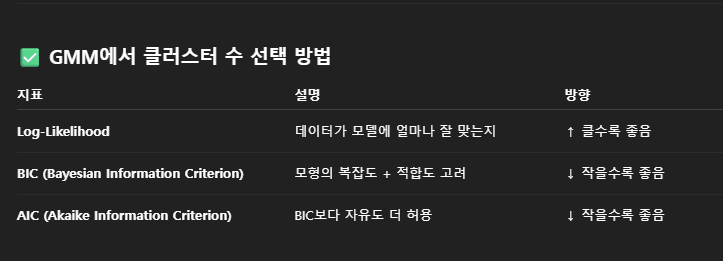

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

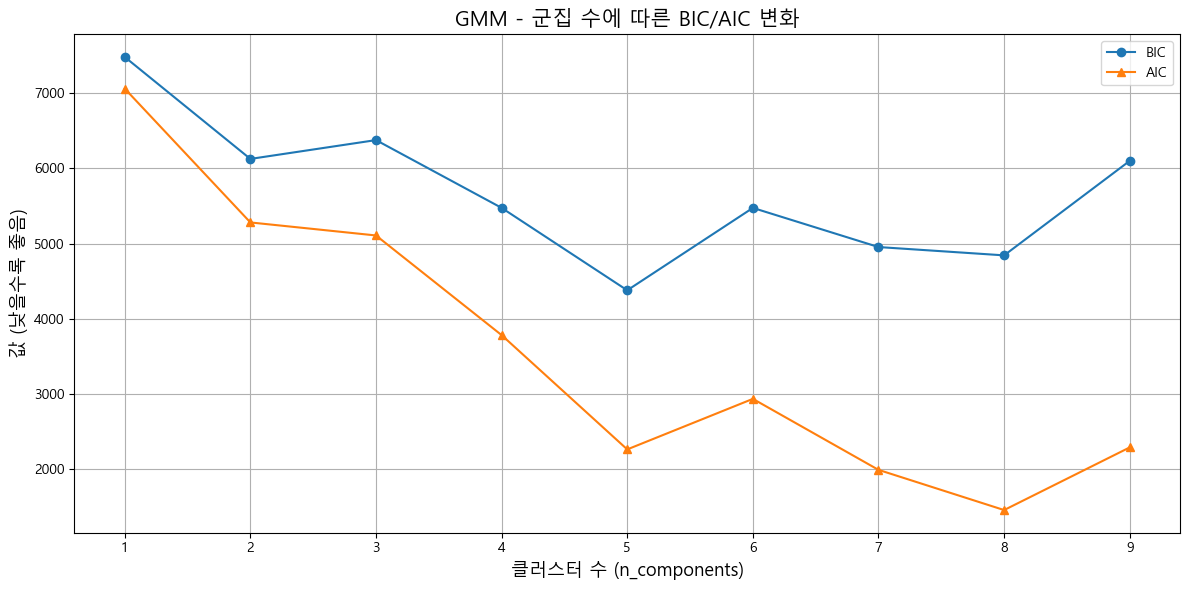

In [349]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import os
os.environ["OMP_NUM_THREADS"] = "1"

X = cluster_df_reduced.copy()  # 결측치 제거된 정규화 없는 feature

n_range = range(1, 10)
bics = []
aics = []
log_likelihoods = []

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X)
    bics.append(gmm.bic(X))
    aics.append(gmm.aic(X))
    log_likelihoods.append(gmm.score(X) * len(X))  # 전체 로그 가능도

# 📈 시각화
plt.figure(figsize=(12, 6))

plt.plot(n_range, bics, label='BIC', marker='o')
plt.plot(n_range, aics, label='AIC', marker='^')
plt.title('GMM - 군집 수에 따른 BIC/AIC 변화', fontsize=15)
plt.xlabel('클러스터 수 (n_components)', fontsize=13)
plt.ylabel('값 (낮을수록 좋음)', fontsize=13)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

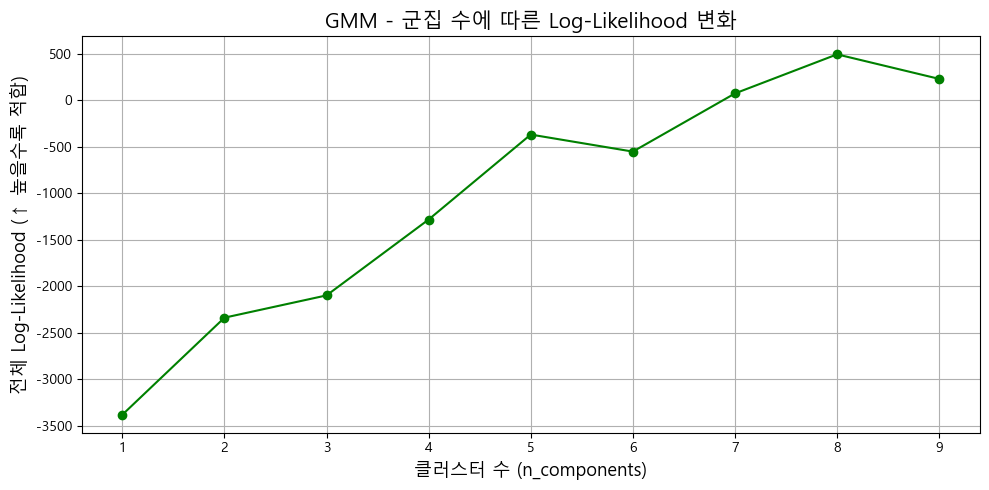

In [350]:
X = cluster_df_reduced.copy()

n_range = range(1, 10)
log_likelihoods = []

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X)
    # 전체 로그 가능도 = 샘플당 평균 * 샘플 수
    log_likelihood = gmm.score(X) * len(X)
    log_likelihoods.append(log_likelihood)

# 📈 시각화
plt.figure(figsize=(10, 5))
plt.plot(n_range, log_likelihoods, marker='o', color='green')
plt.title('GMM - 군집 수에 따른 Log-Likelihood 변화', fontsize=15)
plt.xlabel('클러스터 수 (n_components)', fontsize=13)
plt.ylabel('전체 Log-Likelihood (↑ 높을수록 적합)', fontsize=13)
plt.grid(True)
plt.tight_layout()
plt.show()

#### 클러스터 개수는 3으로

In [351]:
# 클러스터링용 데이터
X = cluster_df_reduced.copy()  # 결측치 제거된 상태라고 가정

# GMM 클러스터링 (n_components=3)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)

# 클러스터 라벨 추가
clustered_df = X.copy()
clustered_df['cluster'] = gmm_labels

# 클러스터별 평균 특성값 계산
cluster_means = clustered_df.groupby('cluster').mean().round(2)

print(cluster_means)


         schedule  distance_km  duration_min  attraction_count  difficulty  shelter_count  dist_to_nearest_parking_km  walkable_to_public_transport  start_dist_to_1_foods  start_dist_to_50_foods  start_dist_to_70_foods  start_dist_to_100_foods  start_dist_to_1_stays  start_dist_to_10_stays  start_dist_to_20_stays  start_dist_to_30_stays
cluster                                                                                                                                                                                                                                                                                                                                           
0            1.00         5.46        172.44              4.35        1.84           0.07                        0.56                          0.90                   2.45                   13.62                   15.64                    17.29                   1.93                    4.63                    5.83        

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [352]:
merge.dist_to_nearest_parking_km.describe()

count    118.000000
mean       0.614237
std        0.961879
min        0.000000
25%        0.094750
50%        0.410000
75%        0.644000
max        6.600000
Name: dist_to_nearest_parking_km, dtype: float64

In [353]:
cluster_means

,schedule,distance_km,duration_min,attraction_count,difficulty,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays
cluster,,,,,,,,,,,,,,,,
0,1.00,5.46,172.44,4.35,1.84,0.07,0.56,0.90,2.45,13.62,15.64,17.29,1.93,4.63,5.83,6.45
1,1.78,20.22,727.78,7.56,2.89,1.44,0.43,0.78,3.63,13.23,15.57,17.17,1.89,5.13,6.70,7.90
2,1.09,10.56,356.96,5.96,2.22,0.26,0.91,0.61,0.77,5.63,6.40,7.55,1.91,7.29,9.14,10.37


#### 주차장 거리 999인 것들 어떻게??

In [354]:
display(len(merge[merge['dist_to_nearest_parking_km'] == 999]))
display(merge[merge['dist_to_nearest_parking_km'] == 999])

0

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays


In [355]:
# 네이버지도 기준

merge.loc[merge['start_point_name'] == '송추분소', 'dist_to_nearest_parking_km'] = 0.410 # 북한산국립공원 송추제2주차장
merge.loc[merge['start_point_name'] == '백운탐방지원센터', 'dist_to_nearest_parking_km'] = 0.071 # 도선사광장주차장
merge.loc[merge['start_point_name'] == '구기탐방지원센터', 'dist_to_nearest_parking_km'] = 0.775 # 비봉공영주차장
merge.loc[merge['start_point_name'] == '비봉탐방지원센터', 'dist_to_nearest_parking_km'] = 0.815 # 비봉공영주차장
merge.loc[merge['start_point_name'] == '백련공원지킴터', 'dist_to_nearest_parking_km'] = 0.21   # 아카데미공영주차장
merge.loc[merge['start_point_name'] == '소귀천공원지킴터', 'dist_to_nearest_parking_km'] = 0.128 # 할렐루야기도원 주차장
merge.loc[merge['start_point_name'] == '증심교', 'dist_to_nearest_parking_km'] = 0.526 # 증심사이주단지 공영 주차장 
merge.loc[merge['start_point_name'] == '너릿재 체육쉼터', 'dist_to_nearest_parking_km'] = 3.8 # 너릿재유아숲 공영 주차장
merge.loc[merge['start_point_name'] == '도원탐방지원센터', 'dist_to_nearest_parking_km'] = 0.028 # 도원마을쉼터주차장
merge.loc[merge['start_point_name'] == '장수대분소', 'dist_to_nearest_parking_km'] = 0.365 # 설악산국립공원 한계산성분소 주차장
merge.loc[merge['start_point_name'] == '남설악탐방지원센터', 'dist_to_nearest_parking_km'] = 0.414 # 오색그린야드호텔 공영 주차장
merge.loc[merge['start_point_name'] == '영각탐방지원센터', 'dist_to_nearest_parking_km'] = 1 # 영각사주차장

In [356]:
display(merge[merge['dist_to_nearest_parking_km'] == 999])

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays


In [357]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Windows MKL memory leak 방지
os.environ["OMP_NUM_THREADS"] = "1"

# 사용할 컬럼
selected_columns_reduced = [
    'schedule', 'distance_km', 'duration_min', 'attraction_count', 'difficulty',
    'shelter_count', 'dist_to_nearest_parking_km', 'walkable_to_public_transport',
    'start_dist_to_1_foods', 'start_dist_to_50_foods', 'start_dist_to_70_foods',
    'start_dist_to_100_foods', 'start_dist_to_1_stays', 'start_dist_to_10_stays',
    'start_dist_to_20_stays', 'start_dist_to_30_stays'
]

# 결측 제거
cluster_df_reduced = merge[selected_columns_reduced].copy().dropna()

# 연속형 피처와 범주형 피처 분리
categorical_cols = ['walkable_to_public_transport']
numerical_cols = [col for col in selected_columns_reduced if col not in categorical_cols]

# 스케일러 정의
scalers = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "MinMaxScaler": MinMaxScaler()
}

results = []

for scaler_name, scaler in scalers.items():
    # 연속형 변수만 스케일링
    X_num_scaled = scaler.fit_transform(cluster_df_reduced[numerical_cols])
    
    # 스케일된 연속형 변수와 범주형 변수 합치기
    X_combined = pd.DataFrame(X_num_scaled, columns=numerical_cols, index=cluster_df_reduced.index)
    X_combined[categorical_cols] = cluster_df_reduced[categorical_cols]  # 그대로 추가

    X = X_combined.values

    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X)
    kmeans_score = silhouette_score(X, kmeans_labels)

    # DBSCAN
    dbscan = DBSCAN(eps=2, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X)
    dbscan_score = silhouette_score(X, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

    # GMM
    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm_labels = gmm.fit_predict(X)
    gmm_score = silhouette_score(X, gmm_labels)

    results += [
        {"Scaler": scaler_name, "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
        {"Scaler": scaler_name, "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
        {"Scaler": scaler_name, "Algorithm": "GMM", "Silhouette Score": gmm_score},
    ]

# 결과 정렬
results_df = pd.DataFrame(results).sort_values(by="Silhouette Score", ascending=False)
print(results_df)


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


           Scaler Algorithm  Silhouette Score
0  StandardScaler    KMeans          0.483484
2  StandardScaler       GMM          0.483484
8    MinMaxScaler       GMM          0.390211
6    MinMaxScaler    KMeans          0.354205
3    RobustScaler    KMeans          0.291594
5    RobustScaler       GMM          0.279486
4    RobustScaler    DBSCAN          0.269590
1  StandardScaler    DBSCAN          0.238215
7    MinMaxScaler    DBSCAN         -1.000000


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

#### 다시

In [358]:
# # Windows MKL memory leak 방지
# os.environ["OMP_NUM_THREADS"] = "1"

# # 사용할 컬럼
# selected_columns_reduced = [
#     'schedule', 'distance_km', 'duration_min', 'attraction_count', 'difficulty',
#     'shelter_count', 'dist_to_nearest_parking_km', 'walkable_to_public_transport',
#     'start_dist_to_1_foods', 'start_dist_to_50_foods', 'start_dist_to_70_foods',
#     'start_dist_to_100_foods', 'start_dist_to_1_stays', 'start_dist_to_10_stays',
#     'start_dist_to_20_stays', 'start_dist_to_30_stays'
# ]

# # 결측 제거
# cluster_df_reduced = merge[selected_columns_reduced].copy().dropna()

# # 정규화 스케일러 정의
# scalers = {
#     "StandardScaler": StandardScaler(),
#     "RobustScaler": RobustScaler(),
#     "MinMaxScaler": MinMaxScaler()
# }

# results = []

# for scaler_name, scaler in scalers.items():
#     X_scaled = scaler.fit_transform(cluster_df_reduced)

#     # KMeans
#     kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
#     kmeans_labels = kmeans.fit_predict(X_scaled)
#     kmeans_score = silhouette_score(X_scaled, kmeans_labels)

#     # DBSCAN
#     dbscan = DBSCAN(eps=2, min_samples=5)
#     dbscan_labels = dbscan.fit_predict(X_scaled)
#     dbscan_score = silhouette_score(X_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

#     # GMM
#     gmm = GaussianMixture(n_components=3, random_state=42)
#     gmm_labels = gmm.fit_predict(X_scaled)
#     gmm_score = silhouette_score(X_scaled, gmm_labels)

#     results += [
#         {"Scaler": scaler_name, "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
#         {"Scaler": scaler_name, "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
#         {"Scaler": scaler_name, "Algorithm": "GMM", "Silhouette Score": gmm_score},
#     ]

# # 결과 정렬
# results_df = pd.DataFrame(results).sort_values(by="Silhouette Score", ascending=False)
# print(results_df)


In [359]:
# 결측치 제거된 원본 feature 사용
X = cluster_df_reduced.copy()

results = []

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
kmeans_score = silhouette_score(X, kmeans_labels)

# DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)
dbscan_score = silhouette_score(X, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

# GMM
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)
gmm_score = silhouette_score(X, gmm_labels)

# 결과 정리
results += [
    {"Scaler": "None", "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
    {"Scaler": "None", "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
    {"Scaler": "None", "Algorithm": "GMM", "Silhouette Score": gmm_score}
]

results_df = pd.DataFrame(results)
print(results_df)

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  Scaler Algorithm  Silhouette Score
0   None    KMeans          0.545418
1   None    DBSCAN         -1.000000
2   None       GMM          0.369372


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

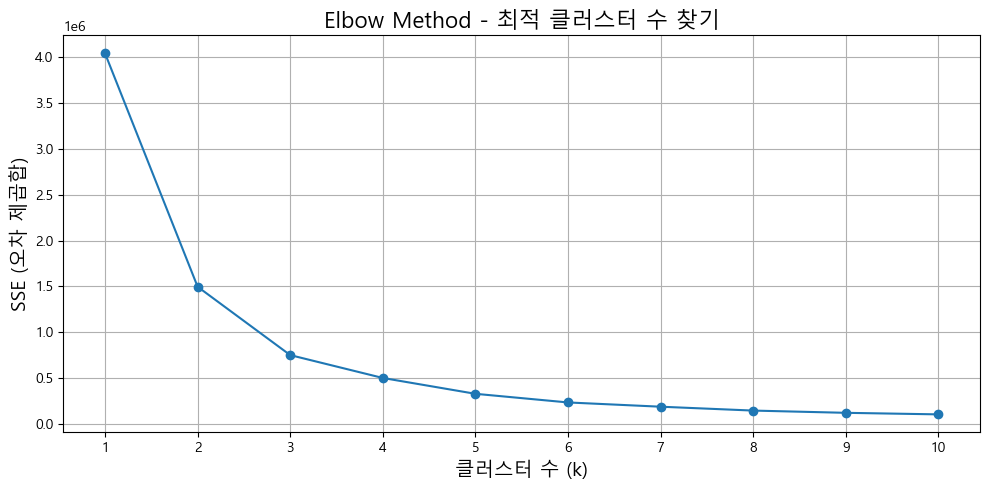

In [360]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 사용할 데이터 (정규화 없이 사용한 것과 동일)
X = cluster_df_reduced.values  # 또는 np.array(cluster_df_reduced)

sse = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # SSE

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method - 최적 클러스터 수 찾기', fontsize=16)
plt.xlabel('클러스터 수 (k)', fontsize=14)
plt.ylabel('SSE (오차 제곱합)', fontsize=14)
plt.grid(True)
plt.xticks(k_range)
plt.tight_layout()
plt.show()


In [361]:
# 세 개 클러스터로 진행

# KMeans 클러스터링
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df_reduced['cluster'] = kmeans_final.fit_predict(cluster_df_reduced)

# 클러스터별 데이터 개수
cluster_counts = cluster_df_reduced['cluster'].value_counts().sort_index()
print("클러스터별 데이터 수:")
print(cluster_counts)

# 클러스터별 평균값
cluster_means = cluster_df_reduced.groupby('cluster').mean()
print("\n클러스터별 평균값:")
print(cluster_means)


클러스터별 데이터 수:
cluster
0    69
1    38
2    11
Name: count, dtype: int64

클러스터별 평균값:
         schedule  distance_km  duration_min  attraction_count  difficulty  shelter_count  dist_to_nearest_parking_km  walkable_to_public_transport  start_dist_to_1_foods  start_dist_to_50_foods  start_dist_to_70_foods  start_dist_to_100_foods  start_dist_to_1_stays  start_dist_to_10_stays  start_dist_to_20_stays  start_dist_to_30_stays
cluster                                                                                                                                                                                                                                                                                                                                           
0        1.000000     4.539130    137.028986          4.057971    1.666667       0.086957                    0.570449                      0.898551               2.973141               15.819421               18.216890                20.16

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [362]:
len(merge)

118

In [363]:
# 클러스터 결과를 merge에 다시 병합
merge_with_cluster = merge.copy()
merge_with_cluster['cluster'] = cluster_df_reduced['cluster']

# 각 클러스터에 속한 course_name 목록 보기
for i in sorted(merge_with_cluster['cluster'].dropna().unique()):
    print(f"\n📌 클러스터 {int(i)}에 속한 코스 목록:")
    print(merge_with_cluster[merge_with_cluster['cluster'] == i]['course_name'].tolist())



📌 클러스터 0에 속한 코스 목록:
['수태골∼동봉', '진남문∼가산봉', '치산지∼동봉', '신일지∼은해봉', '오도암∼비로봉', '탑골∼동봉', '파계사∼파계재', '관암사∼관봉', '동학사 1코스 (편도)', '갑사 1코스 (편도)', '수통골 1코스 (편도)', '천정코스', '구룡계곡코스', '만복대코스', '반야봉코스', '불일폭포코스', '노고단코스', '장각동코스', '문장대1코스', '문장대코스', '세조길코스', '불목이옛길', '북한산성코스', '대남문코스', '사패산코스', '오봉코스', '우이암코스', '망월사_포대_회룡코스', '신선대코스', '백운대코스', '사모바위코스', '비봉코스', '보국문코스', '대동문코스', '소귀천코스', '동대산코스', '비로봉코스', '선재길코스', '용소폭포코스', '울산바위코스', '비룡폭포(토왕폭전망대)코스', '금강굴코스', '양폭코스', '백담사코스', '수렴동코스', '대승폭포코스', '남덕유산코스', '향적봉 2코스', '향적봉 1코스', '삿갓재코스', '서창코스', '월성재코스', '오수자굴코스', '동엽령코스', '횡경재코스', '치목코스', '구천동 어사길 코스', '금대~남대봉', '행구동~향로봉', '성남~남대봉', '부곡~곧은재~비로봉', '구룡~세렴폭포', '구룡~비로봉', '황골~비로봉', '부곡~곧은재~비로봉', '금대~영원산성~남대봉', '부곡~큰무레골~비로봉', '새인봉 - 입석대 코스', '당산나무 코스']

📌 클러스터 1에 속한 코스 목록:
['부인사∼서봉', '동학사 2코스 (종주)', '갑사 2코스 (종주)', '신원사 1코스 (편도)', '신원사 2코스 (종주)', '수통골 2코스 (종주)', '삼신봉코스', '뱀사골계곡코스', '정령치_바래봉코스', '화엄계곡코스', '피아골코스', '중산리(칼바위)코스', '천왕봉1코스', '천왕봉2코스', '장성봉코스', '칠보산코스', '도명산2코스', '도명산1코스', '신선대2코스', '신선대1코스', '문장대

In [364]:
# 클러스터 라벨이 병합된 merge 사용
merge_with_cluster = merge.copy()
merge_with_cluster['cluster'] = cluster_df_reduced['cluster']

# mountain_name별 cluster 분포 집계
cluster_distribution = (
    merge_with_cluster
    .groupby(['mountain_name', 'cluster'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 열 이름 정리
cluster_distribution.columns.name = None
cluster_distribution.columns = ['mountain_name', 'cluster_0', 'cluster_1', 'cluster_2']

print(cluster_distribution)


  mountain_name  cluster_0  cluster_1  cluster_2
0           계룡산          4          5          0
1           덕유산         11          1          1
2           무등산          2          5          0
3           북한산         13          0          0
4           설악산          8          2          4
5           속리산          5         13          0
6           오대산          3          5          0
7           지리산          5          6          5
8           치악산         10          0          1
9           팔공산          8          1          0


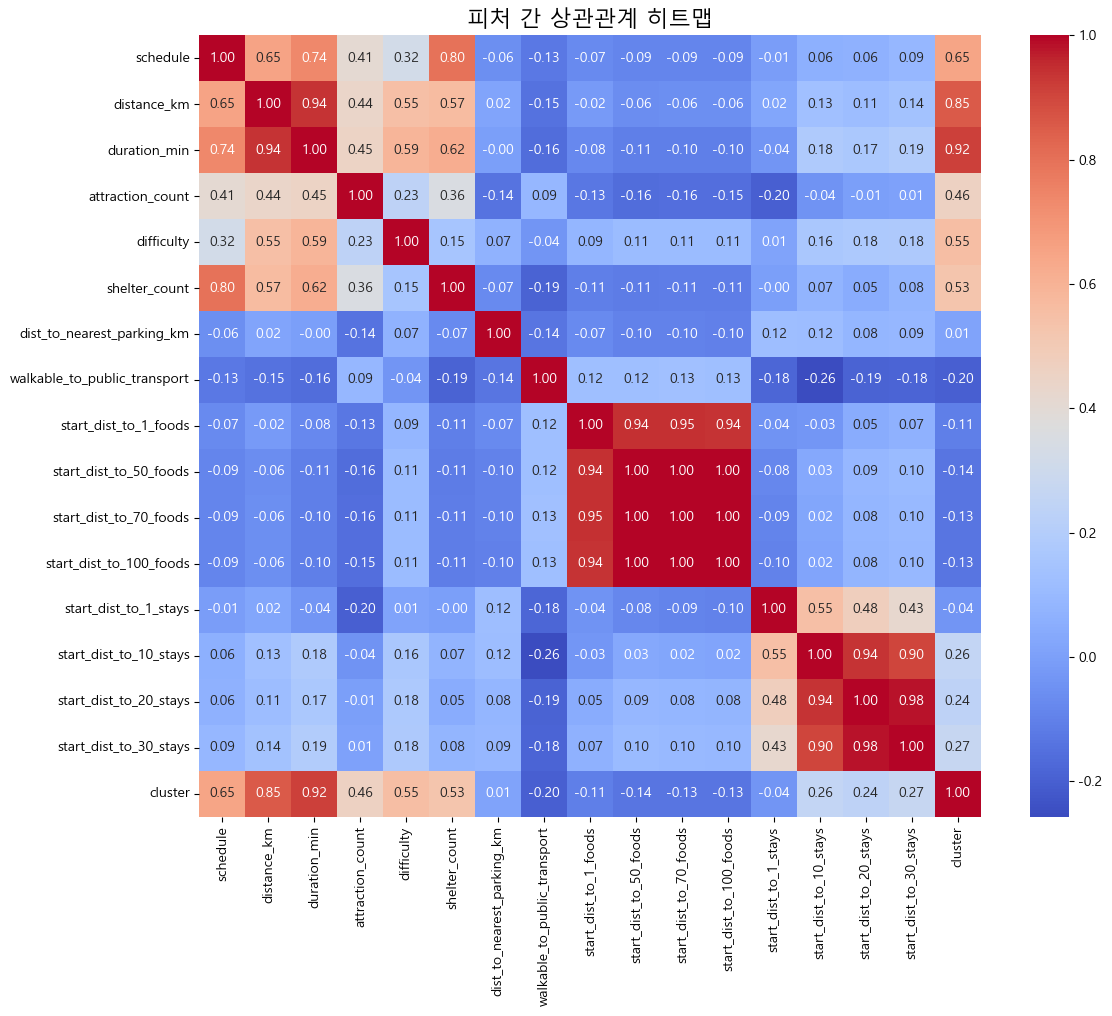

In [365]:
# 상관계수 행렬 계산
corr_matrix = cluster_df_reduced.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("피처 간 상관관계 히트맵", fontsize=16)
plt.tight_layout()
plt.show()

In [366]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# VIF 계산
vif_data = pd.DataFrame()
vif_data["feature"] = cluster_df_reduced.columns
vif_data["VIF"] = [variance_inflation_factor(cluster_df_reduced.values, i) for i in range(cluster_df_reduced.shape[1])]

print(vif_data)


                         feature          VIF
0                       schedule    26.578932
1                    distance_km    34.132388
2                   duration_min    58.956376
3               attraction_count     7.313503
4                     difficulty    15.666596
5                  shelter_count     2.883593
6     dist_to_nearest_parking_km     1.568211
7   walkable_to_public_transport     6.887042
8          start_dist_to_1_foods    23.895485
9         start_dist_to_50_foods  1920.984529
10        start_dist_to_70_foods  4265.435075
11       start_dist_to_100_foods  1915.557270
12         start_dist_to_1_stays     4.332018
13        start_dist_to_10_stays    63.939896
14        start_dist_to_20_stays   278.105566
15        start_dist_to_30_stays   171.738905
16                       cluster    11.343780


#### 결론

1. 실루엣점수가 제일 높은 게 0.609692. 뭔가 애매..?
2. 엘보우에서는 3개가 적절하다고는 하는데 더 늘려야 유저 입장에서는 선택폭이 넓어지는 거 아닐까??
3. 도착지 기준 음식점, 숙소도 할 건가요??

----------------------------------------------------------

### 0702

1. 주차장까지의 거리 라벨링 (사분위 or 500m / 1km 등)
2. 일출/일몰은 정보 제공용. 포함 안함.

In [367]:
merge.head(1)

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.99384,128.68139,동봉,PG_EXT_01,NaN,NaN,1,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,2,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.7,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [368]:
merge.dist_to_nearest_parking_km.describe()

count    118.000000
mean       0.614237
std        0.961879
min        0.000000
25%        0.094750
50%        0.410000
75%        0.644000
max        6.600000
Name: dist_to_nearest_parking_km, dtype: float64

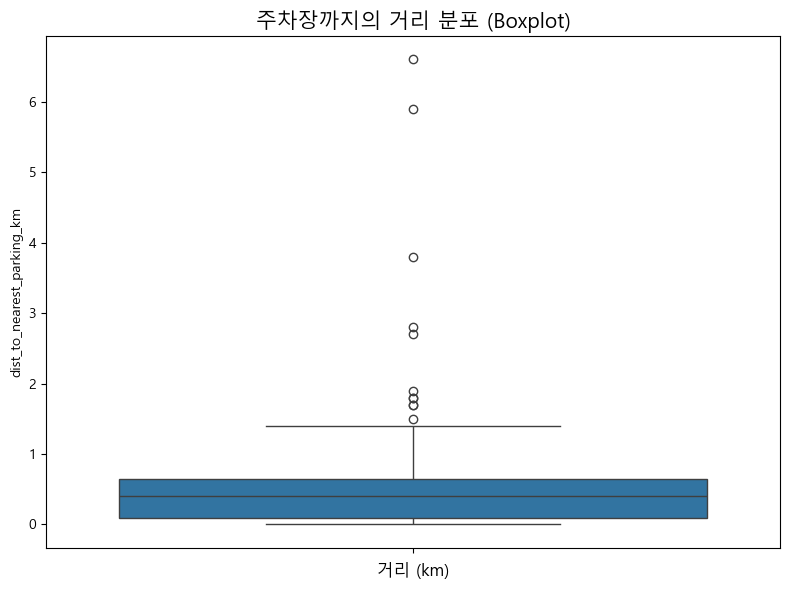

In [369]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=merge['dist_to_nearest_parking_km'])
plt.title('주차장까지의 거리 분포 (Boxplot)', fontsize=15)
plt.xlabel('거리 (km)', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

In [370]:
# 사분위수 기준값 구하기
q1 = merge['dist_to_nearest_parking_km'].quantile(0.25)
q2 = merge['dist_to_nearest_parking_km'].quantile(0.50)
q3 = merge['dist_to_nearest_parking_km'].quantile(0.75)

# 박스플롯 기준 상한 (이상치 기준값)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# 라벨링 함수 정의
def label_parking_dist(x):
    if x > upper_bound:
        return 4  # 이상치
    elif x <= q1:
        return 0
    elif x <= q2:
        return 1
    elif x <= q3:
        return 2
    else:
        return 3

# 적용
merge['parking_dist_label'] = merge['dist_to_nearest_parking_km'].apply(label_parking_dist)
merge.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,parking_dist_label
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,NaN,1,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,2,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.70,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,NaN,1,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,1,19:45:00,17:21:00,0,0.066,1,PG_ENT_02,0.59,1.53,1.92,2.53,1.28,2.70,5.47,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,NaN,1,5.60,190,"치산지, 치산계곡, 수도사, 공산폭포, 동봉",5,2,19:45:00,17:21:00,0,0.735,1,PG_ENT_03,0.55,6.14,6.26,6.49,1.76,6.60,8.77,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,NaN,1,6.30,210,"치신일지, 은해사, 백흥암, 묘봉암, 은해봉",5,2,19:45:00,17:21:00,0,1.500,1,PG_ENT_04,1.48,3.37,3.79,4.49,2.69,7.92,10.07,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,NaN,1,8.40,320,"부인사, 마당재, 벼락 맞은 나무, 서봉, 삼성암터",5,3,19:46:00,17:22:00,0,0.199,1,PG_ENT_05,0.40,2.28,3.55,3.98,1.49,4.89,5.89,6.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [371]:
merge.columns

Index(['mountain_name', 'course_name', 'course_id', 'start_point_name',
       'start_point_id', 'start_lat', 'start_lon', 'end_point_name',
       'end_point_id', 'end_lat', 'end_lon', 'schedule', 'distance_km',
       'duration_min', 'attraction_list', 'attraction_count', 'difficulty',
       'sunset_summer', 'sunset_winter', 'shelter_count',
       'dist_to_nearest_parking_km', 'walkable_to_public_transport',
       'start_place_ID', 'start_dist_to_1_foods', 'start_dist_to_50_foods',
       'start_dist_to_70_foods', 'start_dist_to_100_foods',
       'start_dist_to_1_stays', 'start_dist_to_10_stays',
       'start_dist_to_20_stays', 'start_dist_to_30_stays', 'end_place_ID',
       'end_dist_to_1_foods', 'end_dist_to_50_foods', 'end_dist_to_70_foods',
       'end_dist_to_100_foods', 'end_dist_to_1_stays', 'end_dist_to_10_stays',
       'end_dist_to_20_stays', 'end_dist_to_30_stays', 'parking_dist_label'],
      dtype='object')

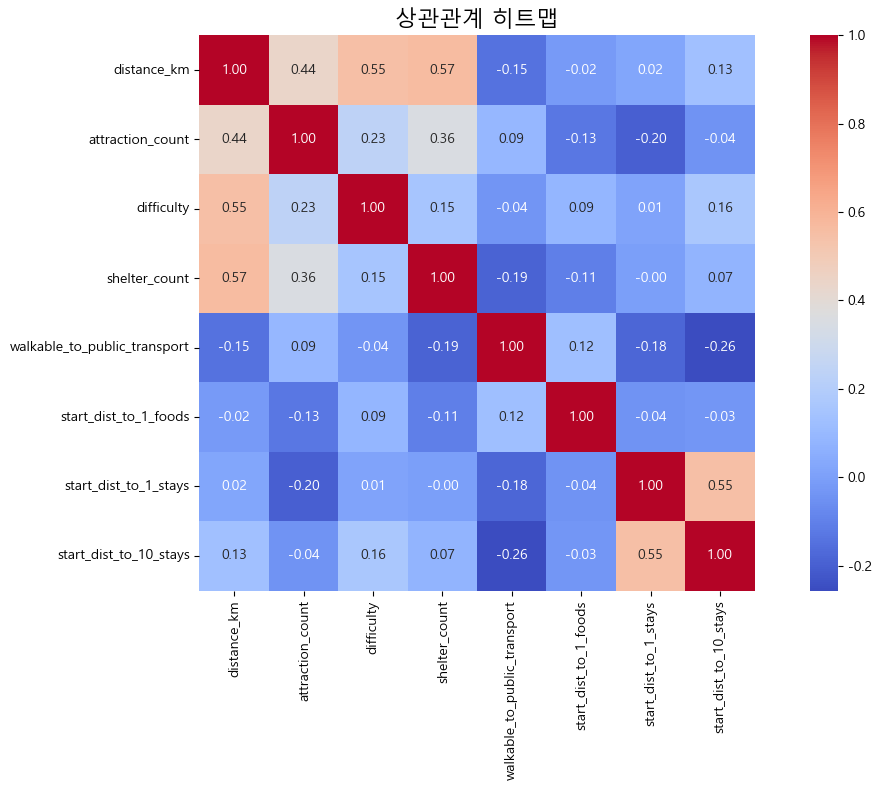

In [372]:
# 분석할 컬럼 리스트
cols = [
    'distance_km',
    'attraction_count', 'difficulty',
    'shelter_count', 
    'walkable_to_public_transport', 'start_dist_to_1_foods',
    'start_dist_to_1_stays',
    'start_dist_to_10_stays']

# 해당 컬럼만 추출
corr_df = merge[cols]

# 상관계수 계산
corr_matrix = corr_df.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("상관관계 히트맵", fontsize=16)
plt.tight_layout()
plt.show()

In [373]:
# 상관관계 확인할 컬럼만 추출 (결측 제거)

cols = ['distance_km',
    'attraction_count', 'difficulty',
    'shelter_count', 
    'walkable_to_public_transport', 'start_dist_to_1_foods',
    'start_dist_to_1_stays',
    'start_dist_to_10_stays', 'parking_dist_label']

X = merge[cols].dropna()

# VIF 계산
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                        feature        VIF
0                   distance_km   7.710653
1              attraction_count   6.389201
2                    difficulty  11.755966
3                 shelter_count   1.862218
4  walkable_to_public_transport   5.164773
5         start_dist_to_1_foods   1.271164
6         start_dist_to_1_stays   3.088785
7        start_dist_to_10_stays   6.335932
8            parking_dist_label   2.520643


In [374]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Windows MKL memory leak 방지
os.environ["OMP_NUM_THREADS"] = "1"

# 전체 사용 컬럼
cols = [
    'distance_km', 'attraction_count', 'difficulty', 'shelter_count',
    'walkable_to_public_transport', 'start_dist_to_1_foods',
    'start_dist_to_1_stays', 'start_dist_to_10_stays', 'parking_dist_label'
]

# 결측 제거
cluster_df_reduced = merge[cols].copy().dropna()

# ✅ 변수 분리
categorical_cols = ['walkable_to_public_transport']
numerical_cols = [col for col in cols if col not in categorical_cols]

# 스케일러 정의
scalers = {
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
    "MinMaxScaler": MinMaxScaler()
}

results = []

for scaler_name, scaler in scalers.items():
    # 연속형 변수 스케일링
    X_num_scaled = scaler.fit_transform(cluster_df_reduced[numerical_cols])
    
    # DataFrame으로 변환 후 범주형 변수 결합
    X_combined = pd.DataFrame(X_num_scaled, columns=numerical_cols, index=cluster_df_reduced.index)
    X_combined[categorical_cols] = cluster_df_reduced[categorical_cols]  # 원본값 그대로 추가
    
    X = X_combined.values

    # KMeans
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X)
    kmeans_score = silhouette_score(X, kmeans_labels)

    # DBSCAN
    dbscan = DBSCAN(eps=2, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X)
    dbscan_score = silhouette_score(X, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

    # GMM
    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm_labels = gmm.fit_predict(X)
    gmm_score = silhouette_score(X, gmm_labels)

    results += [
        {"Scaler": scaler_name, "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
        {"Scaler": scaler_name, "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
        {"Scaler": scaler_name, "Algorithm": "GMM", "Silhouette Score": gmm_score},
    ]

# 결과 정리 및 정렬
results_df = pd.DataFrame(results).sort_values(by="Silhouette Score", ascending=False)
print(results_df)


           Scaler Algorithm  Silhouette Score
3    RobustScaler    KMeans          0.761984
4    RobustScaler    DBSCAN          0.588523
1  StandardScaler    DBSCAN          0.231318
6    MinMaxScaler    KMeans          0.224035
8    MinMaxScaler       GMM          0.215382
0  StandardScaler    KMeans          0.188900
2  StandardScaler       GMM          0.156962
5    RobustScaler       GMM         -0.151532
7    MinMaxScaler    DBSCAN         -1.000000

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

In [375]:
# # Windows MKL memory leak 방지
# os.environ["OMP_NUM_THREADS"] = "1"

# cols = ['distance_km',
#     'attraction_count', 'difficulty',
#     'shelter_count', 
#     'walkable_to_public_transport', 'start_dist_to_1_foods',
#     'start_dist_to_1_stays',
#     'start_dist_to_10_stays', 'parking_dist_label']

# # 사용할 컬럼
# selected_columns_reduced = cols

# # 결측 제거
# cluster_df_reduced = merge[selected_columns_reduced].copy().dropna()

# # 정규화 스케일러 정의
# scalers = {
#     "StandardScaler": StandardScaler(),
#     "RobustScaler": RobustScaler(),
#     "MinMaxScaler": MinMaxScaler()
# }

# results = []

# for scaler_name, scaler in scalers.items():
#     X_scaled = scaler.fit_transform(cluster_df_reduced)

#     # KMeans
#     kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
#     kmeans_labels = kmeans.fit_predict(X_scaled)
#     kmeans_score = silhouette_score(X_scaled, kmeans_labels)

#     # DBSCAN
#     dbscan = DBSCAN(eps=2, min_samples=5)
#     dbscan_labels = dbscan.fit_predict(X_scaled)
#     dbscan_score = silhouette_score(X_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

#     # GMM
#     gmm = GaussianMixture(n_components=3, random_state=42)
#     gmm_labels = gmm.fit_predict(X_scaled)
#     gmm_score = silhouette_score(X_scaled, gmm_labels)

#     results += [
#         {"Scaler": scaler_name, "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
#         {"Scaler": scaler_name, "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
#         {"Scaler": scaler_name, "Algorithm": "GMM", "Silhouette Score": gmm_score},
#     ]

# # 결과 정렬
# results_df = pd.DataFrame(results).sort_values(by="Silhouette Score", ascending=False)
# print(results_df)


In [376]:
# 결측치 제거된 원본 feature 사용
X = cluster_df_reduced.copy()

results = []

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)
kmeans_score = silhouette_score(X, kmeans_labels)

# DBSCAN
dbscan = DBSCAN(eps=2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)
dbscan_score = silhouette_score(X, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

# GMM
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)
gmm_score = silhouette_score(X, gmm_labels)

# 결과 정리
results += [
    {"Scaler": "None", "Algorithm": "KMeans", "Silhouette Score": kmeans_score},
    {"Scaler": "None", "Algorithm": "DBSCAN", "Silhouette Score": dbscan_score},
    {"Scaler": "None", "Algorithm": "GMM", "Silhouette Score": gmm_score}
]

results_df = pd.DataFrame(results)
print(results_df)

  Scaler Algorithm  Silhouette Score
0   None    KMeans          0.388817
1   None    DBSCAN         -0.251151
2   None       GMM         -0.077129


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [377]:
# 세 개 클러스터로 진행

# KMeans 클러스터링
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df_reduced['cluster'] = kmeans_final.fit_predict(cluster_df_reduced)

# 클러스터별 데이터 개수
cluster_counts = cluster_df_reduced['cluster'].value_counts().sort_index()
print("클러스터별 데이터 수:")
print(cluster_counts)

# 클러스터별 평균값
cluster_means = cluster_df_reduced.groupby('cluster').mean()
print("\n클러스터별 평균값:")
print(cluster_means)


클러스터별 데이터 수:
cluster
0    73
1    11
2    34
Name: count, dtype: int64

클러스터별 평균값:
         distance_km  attraction_count  difficulty  shelter_count  walkable_to_public_transport  start_dist_to_1_foods  start_dist_to_1_stays  start_dist_to_10_stays  parking_dist_label
cluster                                                                                                                                                                                  
0           4.941096          4.068493    1.739726       0.068493                      0.835616               0.630056               2.022911                4.842616            1.712329
1           6.472727          3.818182    2.181818       0.000000                      1.000000              17.481048               1.064427                4.695258            1.090909
2          13.611765          7.058824    2.470588       0.588235                      0.764706               0.680091               2.002886                6.085520        

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

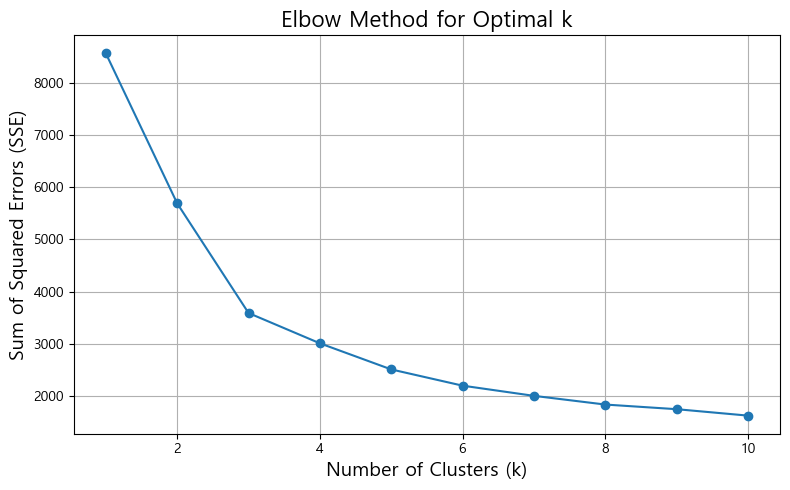

In [378]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 엘보우 메소드용 SSE(오차제곱합) 저장 리스트
sse = []
k_range = range(1, 11)  # k = 1~10까지

# KMeans 반복 수행
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_df_reduced)
    sse.append(kmeans.inertia_)  # inertia_는 SSE 값

# 엘보우 플롯 그리기
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal k', fontsize=16)
plt.xlabel('Number of Clusters (k)', fontsize=14)
plt.ylabel('Sum of Squared Errors (SSE)', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


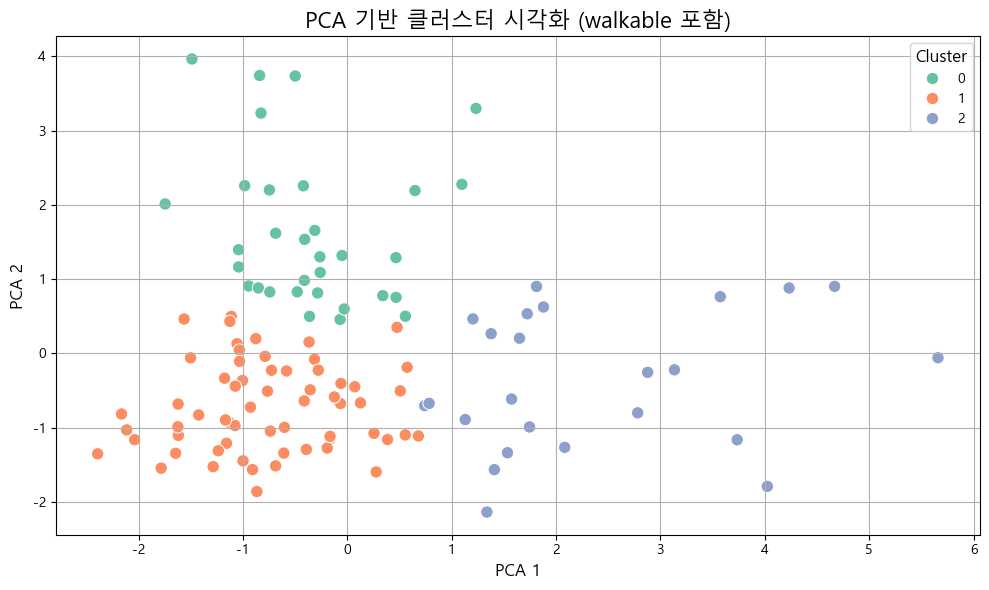


📌 클러스터 0에 속한 코스 목록:
['치산지∼동봉', '신일지∼은해봉', '정령치_바래봉코스', '만복대코스', '피아골코스', '반야봉코스', '칠보산코스', '장각동코스', '신선대2코스', '문장대2코스', '문장대1코스', '대야산코스', '옥녀봉코스', '묘봉코스', '백악산코스', '두로봉코스', '동대산코스', '상왕봉코스', '비로봉코스', '계방산1코스', '계방산2코스', '대승폭포코스', '남덕유산코스', '삿갓재코스', '월성재코스', '오수자굴코스', '동엽령코스', '횡경재코스', '부곡~곧은재~비로봉', '부곡~큰무레골~비로봉', '늦재 - 옛길 코스', '너릿재 - 옛길 코스', '도원마을 - 규봉 코스']

📌 클러스터 1에 속한 코스 목록:
['수태골∼동봉', '진남문∼가산봉', '부인사∼서봉', '오도암∼비로봉', '탑골∼동봉', '파계사∼파계재', '관암사∼관봉', '동학사 1코스 (편도)', '갑사 1코스 (편도)', '신원사 1코스 (편도)', '수통골 1코스 (편도)', '수통골 2코스 (종주)', '천정코스', '구룡계곡코스', '삼신봉코스', '화엄계곡코스', '불일폭포코스', '노고단코스', '신선대1코스', '문장대코스', '세조길코스', '불목이옛길', '북한산성코스', '대남문코스', '사패산코스', '오봉코스', '우이암코스', '망월사_포대_회룡코스', '신선대코스', '백운대코스', '사모바위코스', '비봉코스', '보국문코스', '대동문코스', '소귀천코스', '선재길코스', '용소폭포코스', '울산바위코스', '비룡폭포(토왕폭전망대)코스', '금강굴코스', '양폭코스', '백담사코스', '수렴동코스', '남교리코스', '대청봉코스(오색)', '향적봉 2코스', '향적봉 1코스', '서창코스', '치목코스', '신풍령코스', '구천동 어사길 코스', '금대~남대봉', '행구동~향로봉', '성남~남대봉', '구룡~세렴폭포', '구룡~비로봉', '황골~비로봉', '부곡~곧은재~비로봉', '금대~영원산성

In [379]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ✅ 메모리 누수 방지 (Windows)
os.environ["OMP_NUM_THREADS"] = "1"

# ✅ 사용할 컬럼 정의
numerical_cols = [
    'distance_km', 'attraction_count', 'difficulty',
    'shelter_count', 'start_dist_to_1_foods',
    'start_dist_to_1_stays', 'start_dist_to_10_stays',
    'parking_dist_label'  # 순서형이므로 포함
]
categorical_cols = ['walkable_to_public_transport']  # 이진 변수 → 그대로 사용

# ✅ merge 복사본 생성
merge_with_cluster = merge.copy()

# ✅ 결측치 제거 (모든 변수 포함)
cluster_df_reduced = merge_with_cluster[numerical_cols + categorical_cols].dropna()

# ✅ 정규화 (연속형만)
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(cluster_df_reduced[numerical_cols])

# ✅ 정규화된 연속형 + 0/1 범주형 변수 병합
X_combined = pd.DataFrame(X_num_scaled, columns=numerical_cols, index=cluster_df_reduced.index)
X_combined[categorical_cols] = cluster_df_reduced[categorical_cols].astype(int)  # 0/1 유지

# ✅ KMeans 클러스터링
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_combined)

# ✅ 결과 병합
merge_with_cluster.loc[cluster_df_reduced.index, 'cluster'] = cluster_labels

# ✅ PCA (연속형 + walkable 포함)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

# ✅ PCA 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='Set2', s=80)
plt.title("PCA 기반 클러스터 시각화 (walkable 포함)", fontsize=16)
plt.xlabel("PCA 1", fontsize=12)
plt.ylabel("PCA 2", fontsize=12)
plt.legend(title="Cluster", fontsize=10, title_fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ 클러스터별 course_name 목록 출력
for i in sorted(merge_with_cluster['cluster'].dropna().unique()):
    print(f"\n📌 클러스터 {int(i)}에 속한 코스 목록:")
    course_list = merge_with_cluster[merge_with_cluster['cluster'] == i]['course_name'].dropna().unique().tolist()
    print(course_list)


In [380]:
# 3. mountain_name별 cluster 분포 집계
cluster_distribution = (
    merge_with_cluster
    .dropna(subset=['cluster'])  # 클러스터 없는 row 제외
    .groupby(['mountain_name', 'cluster'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 4. 열 이름 정리
cluster_distribution.columns.name = None
cluster_distribution.columns = ['mountain_name'] + [f'cluster_{int(col)}' for col in cluster_distribution.columns[1:]]

# 5. 출력
print(cluster_distribution)

  mountain_name  cluster_0  cluster_1  cluster_2
0           계룡산          0          6          3
1           덕유산          6          6          1
2           무등산          3          2          2
3           북한산          0         13          0
4           설악산          1          9          4
5           속리산          9          4          5
6           오대산          6          1          1
7           지리산          4          5          7
8           치악산          2          8          1
9           팔공산          2          7          0


In [381]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 분석에 사용할 컬럼
# cols = [
#     'distance_km', 'attraction_count', 'difficulty', 'shelter_count',
#     'walkable_to_public_transport', 'start_dist_to_1_foods',
#     'start_dist_to_1_stays', 'start_dist_to_10_stays', 'parking_dist_label'
# ]

# # 결측치 제거
# X = merge[cols].dropna()

# # ✅ 클러스터링 (예: KMeans로 수행했다면 아래처럼)
# from sklearn.cluster import KMeans
# kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
# cluster_labels = kmeans.fit_predict(X)

# # 클러스터 라벨을 merge에 반영 (결측치 제거한 인덱스 기준)
# merge.loc[X.index, 'cluster'] = cluster_labels

# # ✅ PCA 차원 축소
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X)

# # ✅ 시각화
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='Set2', s=80)
# plt.title("PCA 기반 클러스터 시각화", fontsize=16)
# plt.xlabel("PCA 1", fontsize=12)
# plt.ylabel("PCA 2", fontsize=12)
# plt.legend(title="Cluster", fontsize=10, title_fontsize=12)
# plt.grid(True)
# plt.tight_layout()
# plt.show()



In [382]:
# # 1. merge 복사본 생성
# merge_with_cluster = merge.copy()

# # 2. cluster_df_reduced의 KMeans 클러스터 결과를 merge_with_cluster에 저장
# merge_with_cluster.loc[cluster_df_reduced.index, 'cluster'] = cluster_df_reduced['cluster']

# # 3. 각 클러스터에 속한 course_name 목록 출력
# for i in sorted(merge_with_cluster['cluster'].dropna().unique()):
#     print(f"\n📌 클러스터 {int(i)}에 속한 코스 목록:")
#     print(merge_with_cluster[merge_with_cluster['cluster'] == i]['course_name'].tolist())


In [383]:
# # 1. merge 복사본 생성
# merge_with_cluster = merge.copy()

# # 2. cluster_df_reduced의 KMeans 클러스터 결과를 merge_with_cluster에 저장
# merge_with_cluster.loc[cluster_df_reduced.index, 'cluster'] = cluster_df_reduced['cluster']

# # 3. mountain_name별 cluster 분포 집계
# cluster_distribution = (
#     merge_with_cluster
#     .groupby(['mountain_name', 'cluster'])
#     .size()
#     .unstack(fill_value=0)
#     .reset_index()
# )

# # 4. 열 이름 정리
# cluster_distribution.columns.name = None
# cluster_distribution.columns = ['mountain_name'] + [f'cluster_{int(col)}' for col in cluster_distribution.columns[1:]]

# # 5. 출력
# print(cluster_distribution)


In [384]:
from sklearn.mixture import GaussianMixture

# ✅ GMM 클러스터링 (이미 정규화 + walkable 포함된 X_combined 사용)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_combined)
gmm_labels = gmm.predict(X_combined)

# ✅ 클러스터 라벨 저장
merge_with_cluster.loc[cluster_df_reduced.index, 'gmm_cluster'] = gmm_labels

# ✅ GMM 클러스터별 평균값
gmm_cluster_means = (
    merge_with_cluster
    .dropna(subset=['gmm_cluster'])
    .groupby('gmm_cluster')[numerical_cols + categorical_cols]
    .mean()
)

print("\n📊 GMM 클러스터별 평균값:")
print(gmm_cluster_means)

# ✅ 클러스터별 데이터 수
gmm_cluster_counts = merge_with_cluster['gmm_cluster'].value_counts().sort_index()
print("\n📦 GMM 클러스터별 데이터 수:")
print(gmm_cluster_counts)

# ✅ AIC / BIC
print(f"\n📉 AIC: {gmm.aic(X_combined):,.0f}")
print(f"📉 BIC: {gmm.bic(X_combined):,.0f}")



📊 GMM 클러스터별 평균값:
             distance_km  attraction_count  difficulty  shelter_count  start_dist_to_1_foods  start_dist_to_1_stays  start_dist_to_10_stays  parking_dist_label  walkable_to_public_transport
gmm_cluster                                                                                                                                                                                  
0.0             7.095000          3.450000    1.950000       0.100000               1.183961               4.251112                7.026183            1.800000                          0.35
1.0            15.735714          6.714286    2.571429       1.285714               0.986052               2.022344                6.603687            1.214286                          0.50
2.0             6.339286          4.952381    1.904762       0.059524               2.665771               1.358861                4.512990            1.583333                          1.00

📦 GMM 클러스터별 데이터 수:
gmm_cluster


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

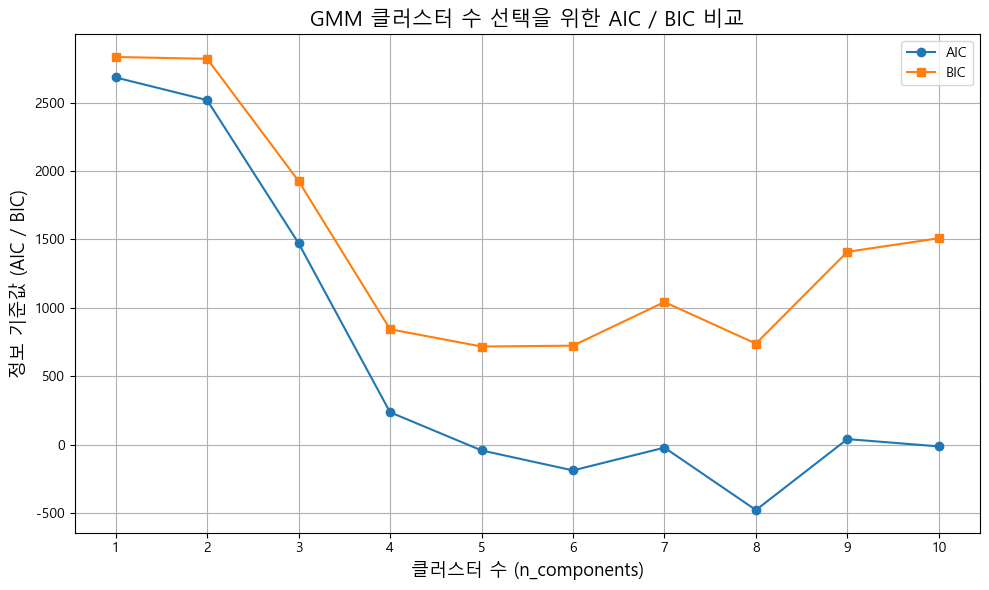

In [385]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# ✅ 클러스터 수 범위
n_components_range = range(1, 11)

# ✅ AIC와 BIC 저장 리스트
aic_values = []
bic_values = []

# ✅ 정규화 + walkable 포함된 feature 사용 (X_combined)
for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_combined)
    aic_values.append(gmm.aic(X_combined))
    bic_values.append(gmm.bic(X_combined))

# ✅ 시각화
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, aic_values, marker='o', label='AIC')
plt.plot(n_components_range, bic_values, marker='s', label='BIC')
plt.xlabel('클러스터 수 (n_components)', fontsize=13)
plt.ylabel('정보 기준값 (AIC / BIC)', fontsize=13)
plt.title('GMM 클러스터 수 선택을 위한 AIC / BIC 비교', fontsize=15)
plt.xticks(n_components_range)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [386]:
# from sklearn.mixture import GaussianMixture

# # GMM 클러스터링
# gmm = GaussianMixture(n_components=3, random_state=42)
# gmm.fit(X)
# gmm_labels = gmm.predict(X)

# # 클러스터 라벨 저장
# merge.loc[X.index, 'gmm_cluster'] = gmm_labels

# # GMM 클러스터별 평균값
# gmm_cluster_means = merge.groupby('gmm_cluster')[cols].mean()
# print("\nGMM 클러스터별 평균값:")
# print(gmm_cluster_means)

# # 클러스터별 데이터 수
# gmm_cluster_counts = merge['gmm_cluster'].value_counts().sort_index()
# print("\nGMM 클러스터별 데이터 수:")
# print(gmm_cluster_counts)

# # AIC, BIC 출력
# print(f"\nAIC: {gmm.aic(X):,.0f}")
# print(f"BIC: {gmm.bic(X):,.0f}")


In [387]:
# from sklearn.mixture import GaussianMixture
# import matplotlib.pyplot as plt

# # 클러스터 수 범위
# n_components_range = range(1, 11)

# # AIC와 BIC 저장 리스트
# aic_values = []
# bic_values = []

# # 각 클러스터 수에 대해 GMM 적합 후 AIC/BIC 계산
# for n in n_components_range:
#     gmm = GaussianMixture(n_components=n, random_state=42)
#     gmm.fit(X)  # X는 정규화 또는 스케일링된 feature 데이터
#     aic_values.append(gmm.aic(X))
#     bic_values.append(gmm.bic(X))

# # 시각화
# plt.figure(figsize=(10, 6))
# plt.plot(n_components_range, aic_values, marker='o', label='AIC')
# plt.plot(n_components_range, bic_values, marker='s', label='BIC')
# plt.xlabel('클러스터 수 (n_components)', fontsize=13)
# plt.ylabel('정보 기준값', fontsize=13)
# plt.title('GMM 클러스터 수에 따른 AIC/BIC 변화', fontsize=15)
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [388]:
from sklearn.mixture import GaussianMixture

# ✅ GMM 클러스터링 (정규화 + walkable 포함 데이터 사용)
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X_combined)
gmm_labels = gmm.predict(X_combined)

# ✅ 클러스터 라벨 병합
merge_with_cluster.loc[cluster_df_reduced.index, 'gmm_cluster'] = gmm_labels

# ✅ GMM 클러스터별 평균값
gmm_cluster_means = (
    merge_with_cluster
    .dropna(subset=['gmm_cluster'])
    .groupby('gmm_cluster')[numerical_cols + categorical_cols]
    .mean()
)

print("\n📊 GMM 클러스터별 평균값:")
print(gmm_cluster_means)

# ✅ GMM 클러스터별 데이터 수
gmm_cluster_counts = (
    merge_with_cluster['gmm_cluster']
    .value_counts()
    .sort_index()
)

print("\n📦 GMM 클러스터별 데이터 수:")
print(gmm_cluster_counts)

# ✅ AIC / BIC
print(f"\n📉 AIC: {gmm.aic(X_combined):,.0f}")
print(f"📉 BIC: {gmm.bic(X_combined):,.0f}")



📊 GMM 클러스터별 평균값:
             distance_km  attraction_count  difficulty  shelter_count  start_dist_to_1_foods  start_dist_to_1_stays  start_dist_to_10_stays  parking_dist_label  walkable_to_public_transport
gmm_cluster                                                                                                                                                                                  
0.0             7.793750          3.312500    1.937500       0.187500               1.025718               2.869576                5.832176            1.875000                      0.125000
1.0            16.875000          7.500000    2.666667       1.500000               0.808206               1.885585                6.151736            1.416667                      0.583333
2.0             7.233333          8.166667    1.666667       0.666667               0.414024               1.575617                4.563966            1.166667                      0.833333
3.0             6.239286        

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [389]:
# from sklearn.mixture import GaussianMixture

# # GMM 클러스터링
# gmm = GaussianMixture(n_components=4, random_state=42)
# gmm.fit(X)
# gmm_labels = gmm.predict(X)

# # 클러스터 라벨 저장
# merge.loc[X.index, 'gmm_cluster'] = gmm_labels

# # GMM 클러스터별 평균값
# gmm_cluster_means = merge.groupby('gmm_cluster')[cols].mean()
# print("\nGMM 클러스터별 평균값:")
# print(gmm_cluster_means)

# # 클러스터별 데이터 수
# gmm_cluster_counts = merge['gmm_cluster'].value_counts().sort_index()
# print("\nGMM 클러스터별 데이터 수:")
# print(gmm_cluster_counts)

# # AIC, BIC 출력
# print(f"\nAIC: {gmm.aic(X):,.0f}")
# print(f"BIC: {gmm.bic(X):,.0f}")


In [390]:
# # NaN 제거한 데이터만 사용
# X = merge[cols].dropna()
# labels = merge.loc[X.index, 'gmm_cluster']

# # PCA로 2차원 축소
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X)

# # 시각화
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='Set2', s=100)
# plt.title('GMM 클러스터링 결과 (PCA 2D)', fontsize=16)
# plt.xlabel('PCA 1')
# plt.ylabel('PCA 2')
# plt.legend(title='Cluster')
# plt.grid(True)
# plt.tight_layout()
# plt.show()


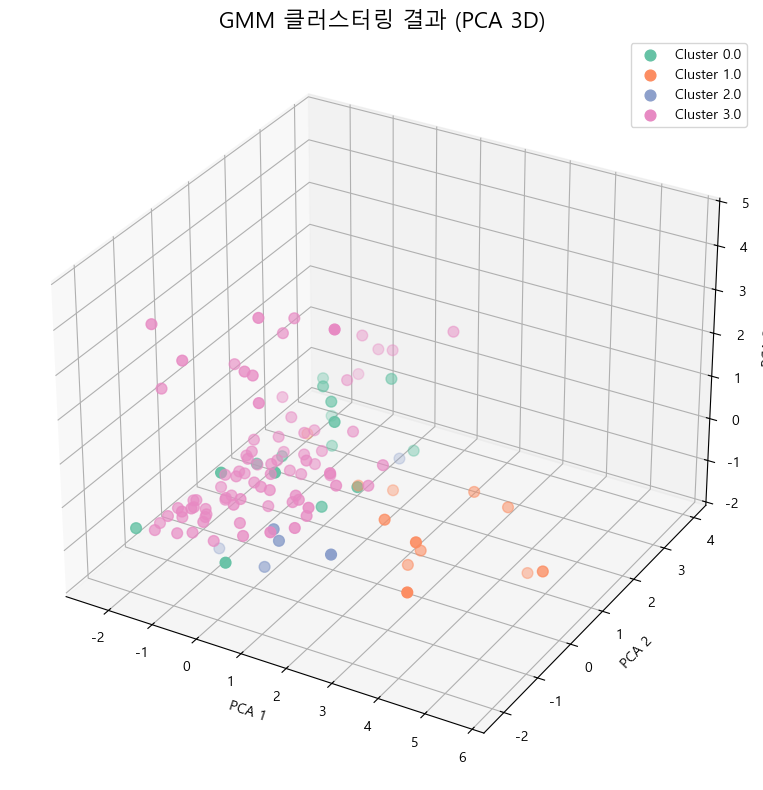

PCA 설명력: [0.27219121 0.20214267 0.13795791]


In [391]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# ✅ 정규화된 feature와 gmm 클러스터 라벨 사용
X = X_combined  # 정규화 + walkable 포함
labels = merge_with_cluster.loc[cluster_df_reduced.index, 'gmm_cluster']

# ✅ PCA (3차원)
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

# ✅ 3D 시각화
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

palette = sns.color_palette("Set2", n_colors=len(np.unique(labels)))

# 클러스터별로 점 찍기
for cluster_id in sorted(np.unique(labels)):
    idx = labels == cluster_id
    ax.scatter(
        X_pca_3d[idx, 0], X_pca_3d[idx, 1], X_pca_3d[idx, 2],
        label=f'Cluster {cluster_id}', s=60,
        color=palette[int(cluster_id)]
    )

ax.set_title('GMM 클러스터링 결과 (PCA 3D)', fontsize=16)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.legend()
plt.tight_layout()
plt.show()
print("PCA 설명력:", pca_3d.explained_variance_ratio_)

In [392]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D  # 3D 그래프를 위한 모듈
# import seaborn as sns

# # 결측치 제거한 데이터와 클러스터 라벨
# X = merge[cols].dropna()
# labels = merge.loc[X.index, 'gmm_cluster']

# # PCA로 3차원 축소
# pca_3d = PCA(n_components=3)
# X_pca_3d = pca_3d.fit_transform(X)

# # 3D 시각화
# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection='3d')

# # 각 클러스터에 대해 점 찍기
# for cluster_id in sorted(labels.unique()):
#     idx = labels == cluster_id
#     ax.scatter(
#         X_pca_3d[idx, 0], X_pca_3d[idx, 1], X_pca_3d[idx, 2],
#         label=f'Cluster {cluster_id}', s=60
#     )

# ax.set_title('GMM 클러스터링 결과 (PCA 3D)', fontsize=16)
# ax.set_xlabel('PCA 1')
# ax.set_ylabel('PCA 2')
# ax.set_zlabel('PCA 3')
# ax.legend()
# plt.tight_layout()
# plt.show()


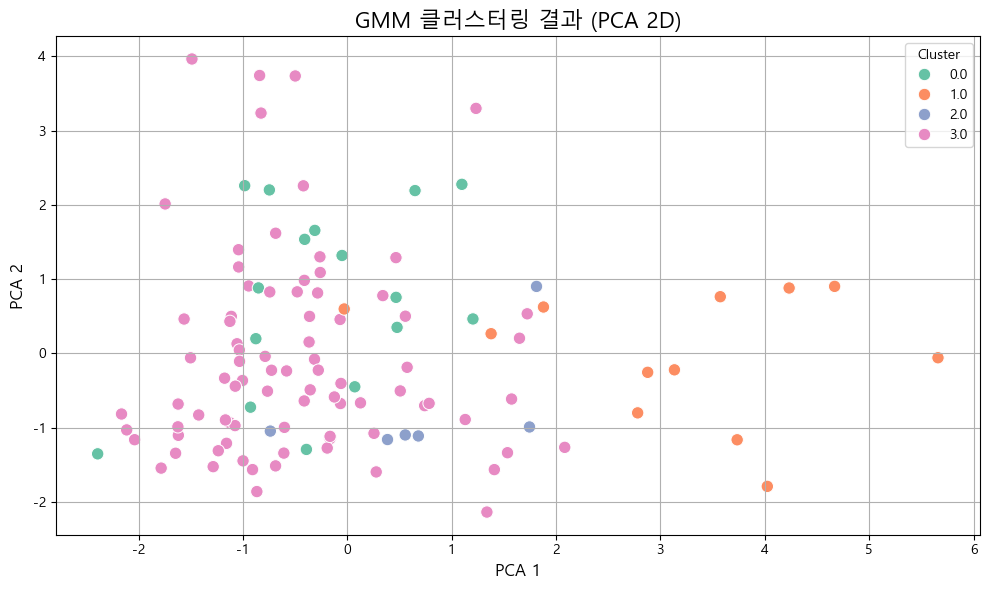

In [393]:
# ✅ PCA 2D 변환
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_combined)
labels = merge_with_cluster.loc[cluster_df_reduced.index, 'gmm_cluster']

# ✅ 2D 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca_2d[:, 0], y=X_pca_2d[:, 1],
    hue=labels, palette='Set2', s=80
)
plt.title('GMM 클러스터링 결과 (PCA 2D)', fontsize=16)
plt.xlabel('PCA 1', fontsize=12)
plt.ylabel('PCA 2', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


In [394]:
# GMM 클러스터링
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(X_pca)  # 또는 X_combined, 또는 PCA 적용된 feature

# GMM 결과를 merge에 저장
merge.loc[X.index, 'gmm_cluster'] = gmm_labels


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [395]:
# GMM 클러스터 라벨을 merge에 저장한 상태라면 아래처럼 진행
merge_with_cluster = merge.copy()

# GMM 클러스터 라벨을 cluster 컬럼에 복사 (또는 cluster라는 이름으로 새로 지정)
merge_with_cluster['cluster'] = merge_with_cluster['gmm_cluster']

# 각 클러스터에 속한 course_name 목록 출력
for i in sorted(merge_with_cluster['cluster'].dropna().unique()):
    print(f"\n📌 클러스터 {int(i)}에 속한 코스 목록:")
    print(merge_with_cluster[merge_with_cluster['cluster'] == i]['course_name'].tolist())



📌 클러스터 0에 속한 코스 목록:
['치산지∼동봉', '신일지∼은해봉', '오도암∼비로봉', '신원사 1코스 (편도)', '수통골 1코스 (편도)', '수통골 2코스 (종주)', '삼신봉코스', '만복대코스', '피아골코스', '노고단코스', '칠보산코스', '장각동코스', '문장대1코스', '대야산코스', '옥녀봉코스', '묘봉코스', '백악산코스', '북한산성코스', '대남문코스', '사모바위코스', '비봉코스', '선재길코스', '계방산1코스', '계방산2코스', '용소폭포코스', '백담사코스', '서창코스', '오수자굴코스', '동엽령코스', '치목코스', '부곡~곧은재~비로봉', '부곡~곧은재~비로봉', '부곡~큰무레골~비로봉', '늦재 - 옛길 코스', '도원마을 - 규봉 코스']

📌 클러스터 1에 속한 코스 목록:
['수태골∼동봉', '진남문∼가산봉', '탑골∼동봉', '파계사∼파계재', '관암사∼관봉', '동학사 1코스 (편도)', '갑사 1코스 (편도)', '천정코스', '구룡계곡코스', '화엄계곡코스', '불일폭포코스', '신선대1코스', '문장대코스', '세조길코스', '불목이옛길', '사패산코스', '오봉코스', '우이암코스', '망월사_포대_회룡코스', '신선대코스', '백운대코스', '보국문코스', '대동문코스', '소귀천코스', '울산바위코스', '비룡폭포(토왕폭전망대)코스', '금강굴코스', '양폭코스', '남교리코스', '대청봉코스(오색)', '향적봉 2코스', '향적봉 1코스', '신풍령코스', '구천동 어사길 코스', '금대~남대봉', '행구동~향로봉', '성남~남대봉', '구룡~세렴폭포', '구룡~비로봉', '황골~비로봉', '금대~영원산성~남대봉', '새인봉 - 입석대 코스', '당산나무 코스']

📌 클러스터 2에 속한 코스 목록:
['부인사∼서봉', '동학사 2코스 (종주)', '갑사 2코스 (종주)', '신원사 2코스 (종주)', '뱀사골계곡코스', '정령치_바래봉코스', '중산리(칼바위)코스', '백무동코스',

In [396]:
# GMM 클러스터 라벨을 기반으로 병합
merge_with_cluster = merge.copy()
merge_with_cluster['cluster'] = merge_with_cluster['gmm_cluster']  # GMM 라벨 사용

# mountain_name별 cluster 분포 집계
cluster_distribution = (
    merge_with_cluster
    .groupby(['mountain_name', 'cluster'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 열 이름 정리
cluster_distribution.columns.name = None
cluster_distribution.columns = ['mountain_name'] + [f'cluster_{int(col)}' for col in cluster_distribution.columns[1:]]

print(cluster_distribution)


  mountain_name  cluster_0  cluster_1  cluster_2  cluster_3  cluster_4
0           계룡산          3          3          3          0          0
1           덕유산          4          4          0          1          4
2           무등산          2          2          2          0          1
3           북한산          4          9          0          0          0
4           설악산          2          6          1          4          1
5           속리산          7          4          7          0          0
6           오대산          3          0          1          0          4
7           지리산          4          3          4          4          1
8           치악산          3          7          1          0          0
9           팔공산          3          5          1          0          0


In [397]:
merge.head()

,mountain_name,course_name,course_id,start_point_name,start_point_id,start_lat,start_lon,end_point_name,end_point_id,end_lat,end_lon,schedule,distance_km,duration_min,attraction_list,attraction_count,difficulty,sunset_summer,sunset_winter,shelter_count,dist_to_nearest_parking_km,walkable_to_public_transport,start_place_ID,start_dist_to_1_foods,start_dist_to_50_foods,start_dist_to_70_foods,start_dist_to_100_foods,start_dist_to_1_stays,start_dist_to_10_stays,start_dist_to_20_stays,start_dist_to_30_stays,end_place_ID,end_dist_to_1_foods,end_dist_to_50_foods,end_dist_to_70_foods,end_dist_to_100_foods,end_dist_to_1_stays,end_dist_to_10_stays,end_dist_to_20_stays,end_dist_to_30_stays,parking_dist_label,gmm_cluster
0,팔공산,수태골∼동봉,PG_01,수태골탐방지원센터,PG_ENT_01,35.993840,128.68139,동봉,PG_EXT_01,NaN,NaN,1,3.85,115,"수릉봉산계표석, 수태골폭포, 동봉, 동봉석조약사여래입상",4,2,19:46:00,17:22:00,0,0.143,1,PG_ENT_01,0.32,1.94,3.95,4.27,0.82,4.70,6.22,7.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0
1,팔공산,진남문∼가산봉,PG_02,진남문(해원정사),PG_ENT_02,36.021210,128.59080,가산봉,PG_EXT_02,NaN,NaN,1,4.70,155,"진남문, 진천주사터(휴게정자), 복수초군락지, 가산산성, 가산봉",5,1,19:45:00,17:21:00,0,0.066,1,PG_ENT_02,0.59,1.53,1.92,2.53,1.28,2.70,5.47,9.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0
2,팔공산,치산지∼동봉,PG_03,치산지,PG_ENT_03,36.043130,128.71520,동봉,PG_EXT_01,NaN,NaN,1,5.60,190,"치산지, 치산계곡, 수도사, 공산폭포, 동봉",5,2,19:45:00,17:21:00,0,0.735,1,PG_ENT_03,0.55,6.14,6.26,6.49,1.76,6.60,8.77,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0.0
3,팔공산,신일지∼은해봉,PG_04,신일지(은해사),PG_ENT_04,35.996310,128.78170,은해봉,PG_EXT_03,NaN,NaN,1,6.30,210,"치신일지, 은해사, 백흥암, 묘봉암, 은해봉",5,2,19:45:00,17:21:00,0,1.500,1,PG_ENT_04,1.48,3.37,3.79,4.49,2.69,7.92,10.07,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,0.0
4,팔공산,부인사∼서봉,PG_05,부인사,PG_ENT_05,35.994623,128.67395,서봉,PG_EXT_04,NaN,NaN,1,8.40,320,"부인사, 마당재, 벼락 맞은 나무, 서봉, 삼성암터",5,3,19:46:00,17:22:00,0,0.199,1,PG_ENT_05,0.40,2.28,3.55,3.98,1.49,4.89,5.89,6.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2.0


c:\Users\syc09\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


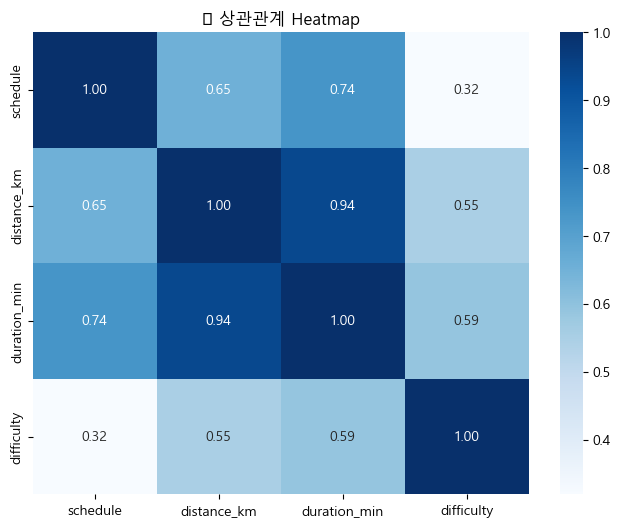

In [398]:
cols = ['schedule', 'distance_km', 'duration_min', 'difficulty']
corr = merge[cols].corr(method='pearson')

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title('📊 상관관계 Heatmap')
plt.show()


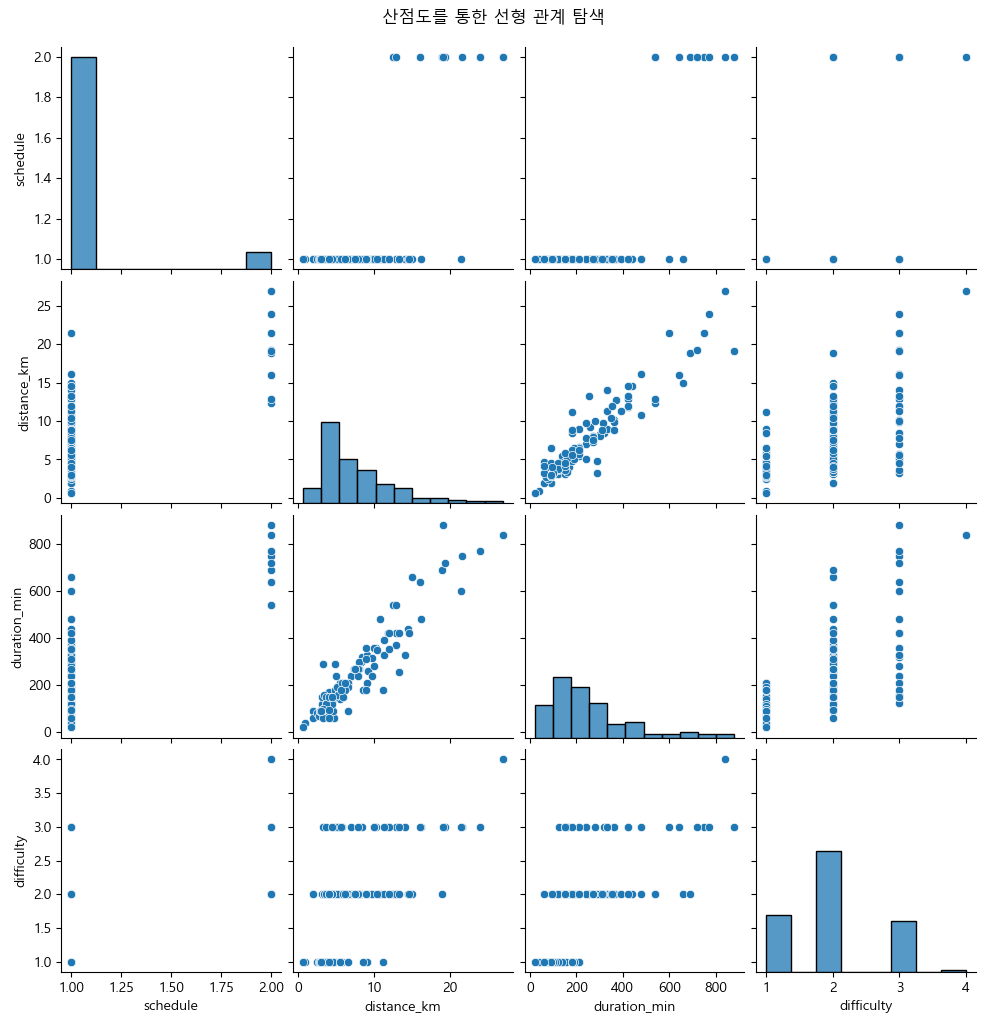

In [399]:
sns.pairplot(merge[cols])
plt.suptitle("산점도를 통한 선형 관계 탐색", y=1.02)
plt.show()

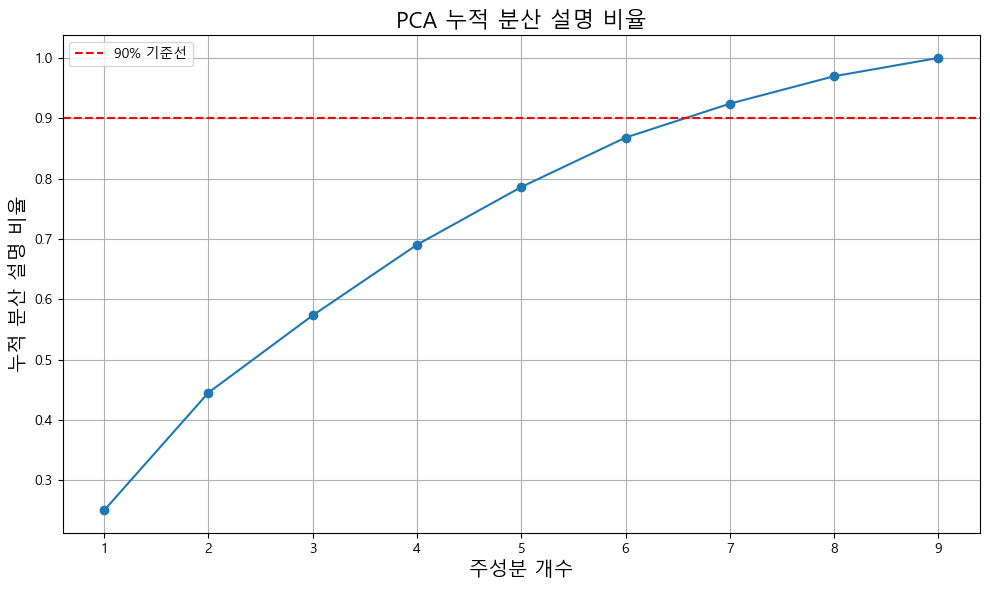

In [400]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

cols = ['distance_km',
    'attraction_count', 'difficulty',
    'shelter_count', 
    'walkable_to_public_transport', 'start_dist_to_1_foods',
    'start_dist_to_1_stays',
    'start_dist_to_10_stays', 'parking_dist_label']

# 1. 정규화 (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[cols])  # X는 DataFrame

# 2. PCA 적용
pca = PCA()
pca.fit(X_scaled)

# 3. 분산 설명 비율 시각화
explained_var = pca.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var)+1), cumulative_var, marker='o')
plt.xlabel('주성분 개수', fontsize=14)
plt.ylabel('누적 분산 설명 비율', fontsize=14)
plt.title('PCA 누적 분산 설명 비율', fontsize=16)
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% 기준선')
plt.legend()
plt.tight_layout()
plt.show()


In [401]:
# 7개 주성분만 사용
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)

# 예: GMM 클러스터링
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X_pca)

# 클러스터 결과 저장
X['gmm_pca_cluster'] = gmm_labels



c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [402]:
# 실제 주성분 개수에 맞춰 인덱스 생성
pca_components = pd.DataFrame(
    pca.components_,
    columns=cols,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# 전치시켜서 각 변수 기준으로 영향도 보기
pca_components.T


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
distance_km,0.587392,-0.067427,0.118003,0.097596,-0.108832,-0.020966,-0.189959
attraction_count,0.406639,-0.336014,-0.123075,-0.057515,0.420472,-0.087559,0.655116
difficulty,0.418001,-0.015645,0.465471,0.170553,0.003782,0.587364,-0.178833
shelter_count,0.480061,-0.063459,-0.252806,-0.005725,-0.232669,-0.564037,-0.299060
walkable_to_public_transport,-0.183322,-0.356395,0.313264,0.316598,0.632027,-0.296020,-0.342626
start_dist_to_1_foods,-0.086786,-0.068851,0.754170,-0.217392,-0.348923,-0.409431,0.278013
start_dist_to_1_stays,0.059525,0.621807,0.085334,0.027983,0.285063,-0.244264,-0.199308
start_dist_to_10_stays,0.194476,0.576761,0.125062,-0.133172,0.315514,-0.036012,0.263361
parking_dist_label,-0.043908,0.164990,-0.022913,0.889963,-0.234935,-0.111964,0.330990


In [403]:
pca_components

,distance_km,attraction_count,difficulty,shelter_count,walkable_to_public_transport,start_dist_to_1_foods,start_dist_to_1_stays,start_dist_to_10_stays,parking_dist_label
PC1,0.587392,0.406639,0.418001,0.480061,-0.183322,-0.086786,0.059525,0.194476,-0.043908
PC2,-0.067427,-0.336014,-0.015645,-0.063459,-0.356395,-0.068851,0.621807,0.576761,0.164990
PC3,0.118003,-0.123075,0.465471,-0.252806,0.313264,0.754170,0.085334,0.125062,-0.022913
PC4,0.097596,-0.057515,0.170553,-0.005725,0.316598,-0.217392,0.027983,-0.133172,0.889963
PC5,-0.108832,0.420472,0.003782,-0.232669,0.632027,-0.348923,0.285063,0.315514,-0.234935
PC6,-0.020966,-0.087559,0.587364,-0.564037,-0.296020,-0.409431,-0.244264,-0.036012,-0.111964
PC7,-0.189959,0.655116,-0.178833,-0.299060,-0.342626,0.278013,-0.199308,0.263361,0.330990


In [404]:
# ✅ PCA 2차원 or 3차원으로 축소
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

# ✅ 클러스터링 (예: GMM or KMeans)
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X_pca_2)

# 결과 병합
df_pca = pd.DataFrame(X_pca_2, columns=['PC1', 'PC2'])
df_pca['cluster'] = gmm_labels

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


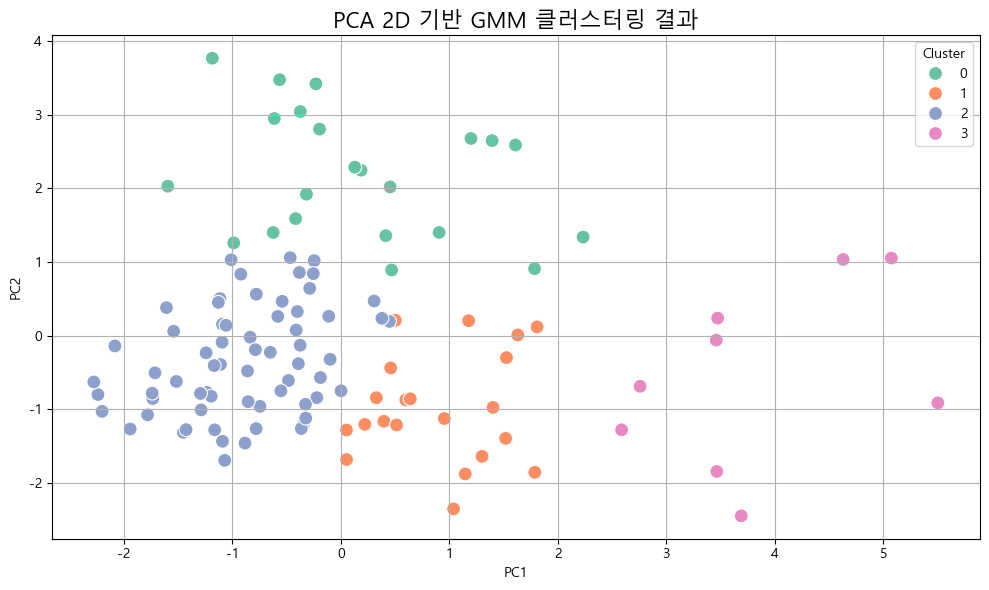

In [405]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='Set2', s=100)
plt.title('PCA 2D 기반 GMM 클러스터링 결과', fontsize=16)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

In [406]:
# 📌 클러스터별 평균값 (주성분 기준)
cluster_means = df_pca.groupby('cluster')[['PC1', 'PC2']].mean()

# 📌 클러스터별 데이터 수
cluster_counts = df_pca['cluster'].value_counts().sort_index()

# ✅ 출력
print("📊 클러스터별 평균값 (PCA 기준):")
print(cluster_means.round(3))

print("\n📈 클러스터별 데이터 수:")
print(cluster_counts)


📊 클러스터별 평균값 (PCA 기준):
           PC1    PC2
cluster              
0        0.168  2.185
1        0.889 -0.925
2       -0.891 -0.351
3        3.849 -0.546

📈 클러스터별 데이터 수:
cluster
0    22
1    22
2    65
3     9
Name: count, dtype: int64


In [407]:
# 실루엣 점수 계산
score = silhouette_score(X_pca_2, gmm_labels)
print(f"🟢 실루엣 점수: {score:.3f}")

🟢 실루엣 점수: 0.379


In [408]:
# ✅ merge 복사본 생성
merge_with_cluster = merge.copy()

# ✅ GMM 클러스터 라벨을 'cluster' 컬럼으로 지정
merge_with_cluster['cluster'] = merge_with_cluster['gmm_cluster']

# ✅ 각 클러스터에 속한 course_name 목록 출력
for i in sorted(merge_with_cluster['cluster'].dropna().unique()):
    course_list = merge_with_cluster[merge_with_cluster['cluster'] == i]['course_name'].tolist()
    
    print(f"\n📌 클러스터 {int(i)}에 속한 코스 목록:")
    print(course_list)



📌 클러스터 0에 속한 코스 목록:
['치산지∼동봉', '신일지∼은해봉', '오도암∼비로봉', '신원사 1코스 (편도)', '수통골 1코스 (편도)', '수통골 2코스 (종주)', '삼신봉코스', '만복대코스', '피아골코스', '노고단코스', '칠보산코스', '장각동코스', '문장대1코스', '대야산코스', '옥녀봉코스', '묘봉코스', '백악산코스', '북한산성코스', '대남문코스', '사모바위코스', '비봉코스', '선재길코스', '계방산1코스', '계방산2코스', '용소폭포코스', '백담사코스', '서창코스', '오수자굴코스', '동엽령코스', '치목코스', '부곡~곧은재~비로봉', '부곡~곧은재~비로봉', '부곡~큰무레골~비로봉', '늦재 - 옛길 코스', '도원마을 - 규봉 코스']

📌 클러스터 1에 속한 코스 목록:
['수태골∼동봉', '진남문∼가산봉', '탑골∼동봉', '파계사∼파계재', '관암사∼관봉', '동학사 1코스 (편도)', '갑사 1코스 (편도)', '천정코스', '구룡계곡코스', '화엄계곡코스', '불일폭포코스', '신선대1코스', '문장대코스', '세조길코스', '불목이옛길', '사패산코스', '오봉코스', '우이암코스', '망월사_포대_회룡코스', '신선대코스', '백운대코스', '보국문코스', '대동문코스', '소귀천코스', '울산바위코스', '비룡폭포(토왕폭전망대)코스', '금강굴코스', '양폭코스', '남교리코스', '대청봉코스(오색)', '향적봉 2코스', '향적봉 1코스', '신풍령코스', '구천동 어사길 코스', '금대~남대봉', '행구동~향로봉', '성남~남대봉', '구룡~세렴폭포', '구룡~비로봉', '황골~비로봉', '금대~영원산성~남대봉', '새인봉 - 입석대 코스', '당산나무 코스']

📌 클러스터 2에 속한 코스 목록:
['부인사∼서봉', '동학사 2코스 (종주)', '갑사 2코스 (종주)', '신원사 2코스 (종주)', '뱀사골계곡코스', '정령치_바래봉코스', '중산리(칼바위)코스', '백무동코스',

In [409]:
# 예: KMeans 클러스터링 결과를 먼저 저장
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)  # 또는 X_combined

# cluster_df_reduced에 클러스터 라벨 추가
cluster_df_reduced['cluster'] = cluster_labels


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [410]:
# 1. merge 복사본 생성
merge_with_cluster = merge.copy()

# 2. cluster_df_reduced의 KMeans 클러스터 결과를 merge_with_cluster에 저장
merge_with_cluster.loc[cluster_df_reduced.index, 'cluster'] = cluster_df_reduced['cluster']

# 3. mountain_name별 cluster 분포 집계
cluster_distribution = (
    merge_with_cluster
    .groupby(['mountain_name', 'cluster'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 4. 열 이름 정리
cluster_distribution.columns.name = None
cluster_distribution.columns = ['mountain_name'] + [f'cluster_{int(col)}' for col in cluster_distribution.columns[1:]]

# 5. 총합 컬럼 추가
cluster_distribution['total_courses'] = cluster_distribution.iloc[:, 1:].sum(axis=1)

# 6. 출력
print(cluster_distribution)


  mountain_name  cluster_0  cluster_1  cluster_2  cluster_3  cluster_4  total_courses
0           계룡산          5          0          4          0          0              9
1           덕유산          6          1          0          0          6             13
2           무등산          1          0          2          0          4              7
3           북한산         11          0          2          0          0             13
4           설악산          7          4          1          0          2             14
5           속리산          9          0          8          0          1             18
6           오대산          1          1          0          0          6              8
7           지리산          6          4          3          0          3             16
8           치악산          0          0          0         11          0             11
9           팔공산          6          0          3          0          0              9


In [411]:
cluster_distribution

,mountain_name,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,total_courses
0,계룡산,5,0,4,0,0,9
1,덕유산,6,1,0,0,6,13
2,무등산,1,0,2,0,4,7
3,북한산,11,0,2,0,0,13
4,설악산,7,4,1,0,2,14
5,속리산,9,0,8,0,1,18
6,오대산,1,1,0,0,6,8
7,지리산,6,4,3,0,3,16
8,치악산,0,0,0,11,0,11
9,팔공산,6,0,3,0,0,9


#### 주성분 등

In [412]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. 사용할 컬럼 정의
numerical_cols = [
    'distance_km', 'attraction_count', 'difficulty',
    'shelter_count', 'start_dist_to_1_foods',
    'start_dist_to_1_stays', 'start_dist_to_10_stays',
    'parking_dist_label'
]
categorical_cols = ['walkable_to_public_transport']  # 스케일링 제외

# 2. 결측치 제거
df = merge[numerical_cols + categorical_cols].dropna()

# 3. 스케일러 정의
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

# 4. 클러스터링 알고리즘 정의
clustering_algorithms = {
    "KMeans": lambda X: KMeans(n_clusters=3, random_state=42).fit_predict(X),
    "GMM": lambda X: GaussianMixture(n_components=3, random_state=42).fit(X).predict(X),
    "DBSCAN": lambda X: DBSCAN(eps=1.5, min_samples=5).fit_predict(X),
}

# 5. 결과 저장용 리스트
full_results = []

# 6. 조합 반복
for scaler_name, scaler in scalers.items():
    # (1) 정규화
    X_num_scaled = scaler.fit_transform(df[numerical_cols])
    
    # (2) 범주형 walkable은 그대로 사용
    X_combined = pd.DataFrame(X_num_scaled, columns=numerical_cols, index=df.index)
    X_combined[categorical_cols] = df[categorical_cols].astype(int)
    X = X_combined.values

    # (3) PCA 분석
    pca = PCA()
    pca.fit(X)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1  # 90% 넘는 최소 주성분 수

    # (4) 클러스터링 알고리즘 루프
    for algo_name, algo_func in clustering_algorithms.items():
        try:
            labels = algo_func(X)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            score = silhouette_score(X, labels) if n_clusters > 1 else -1
        except Exception:
            labels = []
            score = -1
            n_clusters = 0

        full_results.append({
            "Scaler": scaler_name,
            "Clustering": algo_name,
            "Silhouette Score": score,
            "Clusters": n_clusters,
            "PCA 90% 누적설명 주성분 수": n_components_90
        })

# 7. 결과 정리
results_df = pd.DataFrame(full_results).sort_values(by="Silhouette Score", ascending=False)

# 8. 결과 출력
print(results_df.to_string(index=False))


        Scaler Clustering  Silhouette Score  Clusters  PCA 90% 누적설명 주성분 수
  RobustScaler     KMeans          0.280251         3                   2
  MinMaxScaler     KMeans          0.224035         3                   6
  MinMaxScaler        GMM          0.215382         3                   6
StandardScaler        GMM          0.156962         3                   7
StandardScaler     KMeans          0.138783         3                   7
  RobustScaler        GMM         -0.151532         3                   2
StandardScaler     DBSCAN         -1.000000         1                   7
  MinMaxScaler     DBSCAN         -1.000000         1                   6
  RobustScaler     DBSCAN         -1.000000         1                   2


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

In [413]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd

# 1. 사용할 컬럼 정의
numerical_cols = [
    'distance_km', 'attraction_count', 'difficulty',
    'shelter_count', 'start_dist_to_1_foods',
    'start_dist_to_1_stays', 'start_dist_to_10_stays',
    'parking_dist_label'
]
categorical_cols = ['walkable_to_public_transport']

# 2. 결측치 제거
df = merge[numerical_cols + categorical_cols].dropna()

# 3. RobustScaler 정규화
scaler = RobustScaler()
X_num_scaled = scaler.fit_transform(df[numerical_cols])

# 4. 범주형 walkable은 그대로 포함
X_combined = pd.DataFrame(X_num_scaled, columns=numerical_cols, index=df.index)
X_combined['walkable_to_public_transport'] = df['walkable_to_public_transport'].astype(int)

# 5. PCA (7개 주성분 사용)
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_combined)

# 6. KMeans 클러스터링 (n=3)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

# 7. 클러스터 결과 저장
pca_cluster_df = df.copy()
pca_cluster_df['kmeans_pca_cluster'] = kmeans_labels

# 8. 주성분 영향도 분석
pca_components = pd.DataFrame(
    pca.components_,
    columns=X_combined.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# 9. 전치시켜 변수별 주성분 영향도 보기
pca_loading = pca_components.T
pca_loading_sorted = pca_loading.reindex(
    pca_loading.abs().sum(axis=1).sort_values(ascending=False).index
)

# 10. 출력
print("\n📊 변수별 PCA 주성분 영향도 (내림차순 정렬):")
print(pca_loading_sorted)



📊 변수별 PCA 주성분 영향도 (내림차순 정렬):
                                   PC1       PC2       PC3       PC4       PC5       PC6       PC7
attraction_count             -0.022911  0.546753 -0.184037 -0.298229  0.625303 -0.405625 -0.023222
difficulty                    0.012222  0.396978  0.153271  0.245822 -0.549920 -0.521875 -0.125793
start_dist_to_1_stays        -0.007672 -0.124802  0.796672 -0.189976  0.222346 -0.002642 -0.507654
parking_dist_label           -0.012689 -0.083798  0.152903  0.858400  0.443503 -0.115345  0.137298
start_dist_to_10_stays       -0.004660  0.037736  0.490131 -0.206737 -0.033433 -0.187577  0.795084
distance_km                  -0.003291  0.654509  0.176190  0.182979 -0.156674  0.378847 -0.110143
shelter_count                -0.012824  0.300812  0.053184  0.008393  0.155729  0.578576  0.162300
start_dist_to_1_foods         0.999409  0.012047  0.006488 -0.001014  0.028783  0.005216  0.006103
walkable_to_public_transport  0.009551 -0.020823 -0.102133  0.037370  0.098519 

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [414]:
print("\n📈 클러스터별 평균값:")
print(pca_cluster_df.groupby('kmeans_pca_cluster').mean())


📈 클러스터별 평균값:
                    distance_km  attraction_count  difficulty  shelter_count  start_dist_to_1_foods  start_dist_to_1_stays  start_dist_to_10_stays  parking_dist_label  walkable_to_public_transport
kmeans_pca_cluster                                                                                                                                                                                  
0                      5.715663          4.144578    1.795181       0.072289               0.697334               2.139923                5.017564            1.710843                      0.831325
1                      6.472727          3.818182    2.181818       0.000000              17.481048               1.064427                4.695258            1.090909                      1.000000
2                     14.545833          8.041667    2.583333       0.791667               0.468270               1.589876                5.998368            1.333333                      0.750000


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

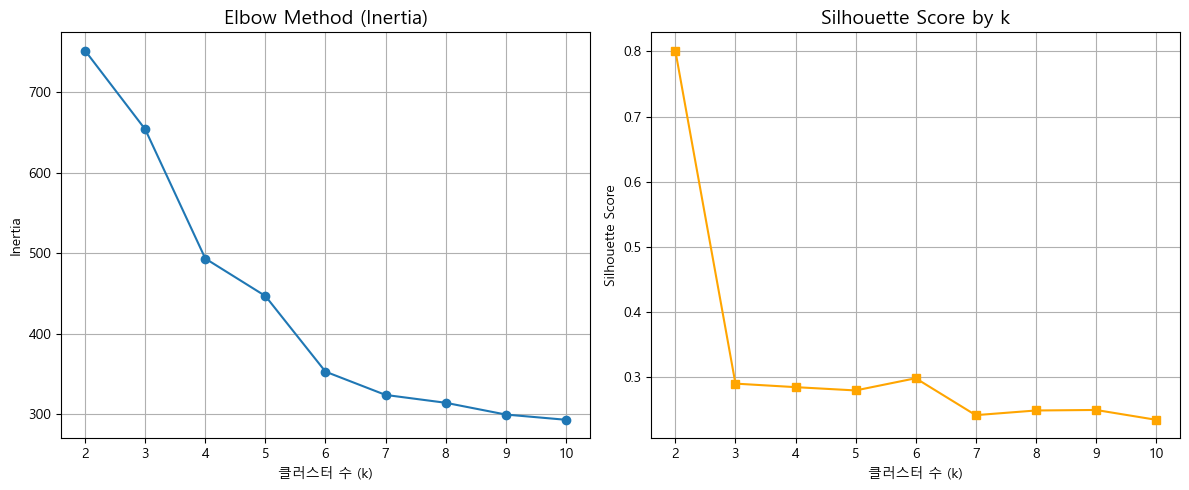

In [415]:
# 이전 셀에서 정의 누락된 X_pca 생성을 다시 포함하여 실행

# 1. 결측치 제거
df = merge[numerical_cols + categorical_cols].dropna()

# 2. RobustScaler 정규화
scaler = RobustScaler()
X_num_scaled = scaler.fit_transform(df[numerical_cols])

# 3. walkable 그대로 추가
X_combined = pd.DataFrame(X_num_scaled, columns=numerical_cols, index=df.index)
X_combined['walkable_to_public_transport'] = df['walkable_to_public_transport'].astype(int)

# 4. PCA (7개 주성분 사용)
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_combined)

# 5. KMeans 적정 클러스터 수 분석
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

# 시각화
plt.figure(figsize=(12, 5))

# Elbow Method (Inertia)
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method (Inertia)', fontsize=14)
plt.xlabel('클러스터 수 (k)')
plt.ylabel('Inertia')
plt.grid(True)

# Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', color='orange')
plt.title('Silhouette Score by k', fontsize=14)
plt.xlabel('클러스터 수 (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()


In [416]:
# 최종 클러스터 수 적용
kmeans = KMeans(n_clusters=5, random_state=42)
final_labels = kmeans.fit_predict(X_pca)

# 결과 저장
df_result = df.copy()
df_result['kmeans_pca_5cluster'] = final_labels

c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [417]:
df_result.head()

,distance_km,attraction_count,difficulty,shelter_count,start_dist_to_1_foods,start_dist_to_1_stays,start_dist_to_10_stays,parking_dist_label,walkable_to_public_transport,kmeans_pca_5cluster
0,3.85,4,2,0,0.32,0.82,4.70,1,1,0
1,4.70,5,1,0,0.59,1.28,2.70,0,1,0
2,5.60,5,2,0,0.55,1.76,6.60,3,1,0
3,6.30,5,2,0,1.48,2.69,7.92,4,1,0
4,8.40,5,3,0,0.40,1.49,4.89,1,1,0


c:\Users\syc09\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


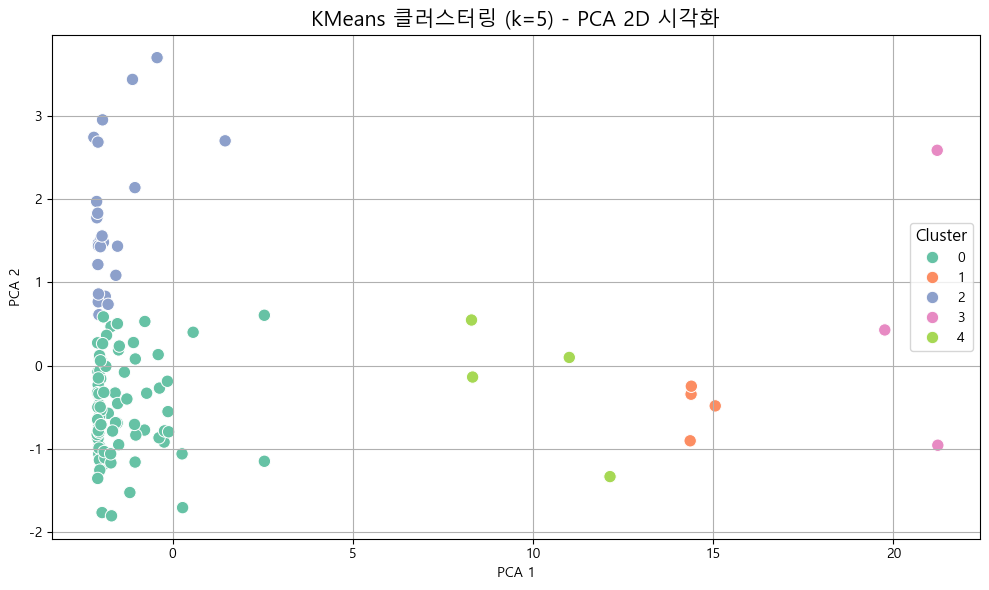

In [418]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 분석 대상 컬럼
cols = ['distance_km', 'attraction_count', 'difficulty',
        'shelter_count', 'walkable_to_public_transport',
        'start_dist_to_1_foods', 'start_dist_to_1_stays',
        'start_dist_to_10_stays', 'parking_dist_label']

# 결측치 제거
X = merge[cols].dropna()

# ✅ 정규화: walkable_to_public_transport만 제외하고 나머지에 적용
scale_cols = [col for col in cols if col != 'walkable_to_public_transport']
scaler = RobustScaler()
X_scaled_part = scaler.fit_transform(X[scale_cols])

# 정규화 안 한 walkable 피처 연결
X_final = pd.DataFrame(X_scaled_part, columns=scale_cols, index=X.index)
X_final['walkable_to_public_transport'] = X['walkable_to_public_transport']

# ✅ PCA (7개 주성분 사용)
pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_final)

# ✅ KMeans 클러스터링 (k=5)
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)

# ✅ 2D PCA 추가 변환 (시각화 용도)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_final)

# ✅ 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca_2d[:, 0], y=X_pca_2d[:, 1],
    hue=kmeans_labels, palette='Set2', s=80
)
plt.title("KMeans 클러스터링 (k=5) - PCA 2D 시각화", fontsize=15)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster", fontsize=10, title_fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [419]:
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

# 보기 좋게 출력
print("📊 각 클러스터별 코스 개수:")
for cluster_id, count in cluster_counts.items():
    print(f" - 클러스터 {cluster_id}: {count}개")

📊 각 클러스터별 코스 개수:
 - 클러스터 0: 83개
 - 클러스터 1: 4개
 - 클러스터 2: 24개
 - 클러스터 3: 3개
 - 클러스터 4: 4개


In [420]:
cluster_counts_df = cluster_counts.reset_index()
cluster_counts_df.columns = ['Cluster', 'Count']
display(cluster_counts_df)

,Cluster,Count
0,0,83
1,1,4
2,2,24
3,3,3
4,4,4


In [421]:
cluster_counts_df.Count.sum()

118

In [422]:
# merge DataFrame의 X.index에 맞춰 클러스터 라벨을 저장
merge_with_cluster = merge.copy()
merge_with_cluster.loc[X.index, 'kmeans_cluster'] = kmeans_labels

# 분석에 사용된 피처 리스트
cols = ['distance_km', 'attraction_count', 'difficulty',
        'shelter_count', 'walkable_to_public_transport',
        'start_dist_to_1_foods', 'start_dist_to_1_stays',
        'start_dist_to_10_stays', 'parking_dist_label']

# 클러스터별 평균값 계산
cluster_summary = merge_with_cluster.groupby('kmeans_cluster')[cols].mean().round(2)

# 출력
print("📊 클러스터별 평균값 요약:")
display(cluster_summary)


📊 클러스터별 평균값 요약:


,distance_km,attraction_count,difficulty,shelter_count,walkable_to_public_transport,start_dist_to_1_foods,start_dist_to_1_stays,start_dist_to_10_stays,parking_dist_label
kmeans_cluster,,,,,,,,,
0.0,5.72,4.14,1.80,0.07,0.83,0.70,2.14,5.02,1.71
1.0,5.40,3.00,2.00,0.00,1.00,17.48,1.74,5.48,2.25
2.0,14.55,8.04,2.58,0.79,0.75,0.47,1.59,6.00,1.33
3.0,10.03,5.00,2.33,0.00,1.00,23.97,0.99,3.44,0.67
4.0,4.88,3.75,2.25,0.00,1.00,12.62,0.44,4.85,0.25


In [423]:
cluster_counts = merge_with_cluster['kmeans_cluster'].value_counts().sort_index()
print("📌 클러스터별 코스 개수:")
for cluster, count in cluster_counts.items():
    print(f" - 클러스터 {int(cluster)}: {count}개")


📌 클러스터별 코스 개수:
 - 클러스터 0: 83개
 - 클러스터 1: 4개
 - 클러스터 2: 24개
 - 클러스터 3: 3개
 - 클러스터 4: 4개


In [424]:
# 1. 복사본 생성
merge_with_cluster = merge.copy()

# 2. 클러스터 라벨 저장 (X.index 기준)
merge_with_cluster.loc[X.index, 'cluster'] = kmeans_labels

# 3. mountain_name별 클러스터 분포 집계
cluster_distribution = (
    merge_with_cluster
    .groupby(['mountain_name', 'cluster'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# 4. 열 이름 정리
cluster_distribution.columns.name = None
cluster_distribution.columns = (
    ['mountain_name'] +
    [f'cluster_{int(col)}' for col in cluster_distribution.columns[1:]]
)

# 5. 출력
print("📊 산별 클러스터 분포:")
display(cluster_distribution)


📊 산별 클러스터 분포:


,mountain_name,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4
0,계룡산,6,0,3,0,0
1,덕유산,12,0,1,0,0
2,무등산,4,0,3,0,0
3,북한산,13,0,0,0,0
4,설악산,10,0,4,0,0
5,속리산,13,0,5,0,0
6,오대산,7,0,1,0,0
7,지리산,9,0,7,0,0
8,치악산,0,4,0,3,4
9,팔공산,9,0,0,0,0
